#  Q-learning

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

__Выполнила Ларькова Дарья__

Материалы:
* Саттон Р.	С.,	Барто Э. Дж. Обучение с подкреплением: Введение. 2-е изд.
* https://gymnasium.farama.org/tutorials/training_agents/blackjack_tutorial/
* https://en.wikipedia.org/wiki/Q-learning
* https://www.baeldung.com/cs/epsilon-greedy-q-learning
* https://pythonprogramming.net/q-learning-reinforcement-learning-python-tutorial/
* https://www.datacamp.com/tutorial/introduction-q-learning-beginner-tutorial
* https://rubikscode.net/2021/07/20/introduction-to-double-q-learning/
* https://gymnasium.farama.org/api/wrappers/misc_wrappers/#gymnasium.wrappers.RecordVideo

## Задачи для совместного разбора

1\. Рассмотрите понятие Q-функции, ее применение для формирования политики агента и способов ее создания.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Обучите агента для игры в блэкджек (окружение `Blackjack-v1`), используя алгоритм Q-learning. Для создания таблицы Q-функции выясните размеры пространства состояния игры и количество возможных действий игрока и выведите эти значения на экран. Во время обучения несколько раз вычислите статистику за `print_every` последних эпизодов: количество выигранных и проигранных сессий. После завершения обучения визуализируйте полученные данные. Изучите, как выглядит Q-функция (в каких состояниях игрок будет брать карту, в каких - нет). Cыграйте `N=10000` игр, применяя стратегию, выведенную из обученной Q-функции, посчитайте и выведите на экран долю выигранных игр.

Cтратегия для выбора действия:
$$a_{t+1}(s_t) = argmax_aQ(s_t, a)$$

Правило обновления Q-функции:

![q-learning](https://wikimedia.org/api/rest_v1/media/math/render/svg/d247db9eaad4bd343e7882ec546bf3847ebd36d8)

- [ ] Проверено на семинаре

In [1]:
# ИСПОЛЬЗУЕМЫЕ БИБЛИОТЕКИ
from dataclasses import dataclass
import gymnasium as gym
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import deque
import seaborn as sns
import random

In [2]:
@dataclass
class Config:
    discount: float = 0.95
    lr: float = 0.01
    n_episodes: int = 2_000_000
    print_every: int = 20_000
    seed: int = 42


In [3]:
class Agent:
    def __init__(self, env: gym.Env, config: Config) -> None:
        self.env = env
        self.cfg = config
        self.rng = np.random.default_rng(config.seed)

        # Размеры пространства состояний и количество действий из окружения
        self.state_shape = tuple(space.n for space in self.env.observation_space.spaces)
        self.n_actions = self.env.action_space.n

        self._create_q_table()

        # Инициализация генератора случайности окружения
        self.env.reset(seed=self.cfg.seed)
        self.env.action_space.seed(self.cfg.seed)

        print(f"Размеры пространства состояний: {self.state_shape}")
        print(f"Количество состояний: {int(np.prod(self.state_shape))}")
        print(f"Количество возможных действий: {self.n_actions}")
        print(f"Размер Q-таблицы: {self.q_table.shape}")

    def _create_q_table(self):
        self.q_table = np.zeros((*self.state_shape, self.n_actions), dtype=np.float64)

    def get_action(self, state: tuple) -> int:
        """Жадная стратегия a(s)=argmax_a Q(s,a)."""
        player_sum, dealer_card, usable_ace = state
        q_values = self.q_table[player_sum, dealer_card, int(usable_ace), :]
        max_q = np.max(q_values)

        # При равенстве Q-значений выбирается одно из лучших действий случайно.
        # Это не ε-greedy: случайность используется только для разрешения ничьей.
        best_actions = np.flatnonzero(q_values == max_q)
        return int(self.rng.choice(best_actions))

    def update_q_table(
        self,
        state: tuple,
        new_state: tuple,
        reward: float,
        action: int,
        done: bool
    ) -> None:
        player_sum, dealer_card, usable_ace = state
        new_player_sum, new_dealer_card, new_usable_ace = new_state

        current_q = self.q_table[player_sum, dealer_card, int(usable_ace), action]

        if done:
            future_q = 0.0
        else:
            future_q = np.max(
                self.q_table[new_player_sum, new_dealer_card, int(new_usable_ace), :]
            )

        # Q-learning update rule
        td_target = reward + self.cfg.discount * future_q
        self.q_table[player_sum, dealer_card, int(usable_ace), action] = (
            current_q + self.cfg.lr * (td_target - current_q)
        )

    def run_episode(self, training: bool = True) -> float:
        state, _ = self.env.reset()

        while True:
            action = self.get_action(state)
            new_state, reward, terminated, truncated, _ = self.env.step(action)
            done = terminated or truncated

            if training:
                self.update_q_table(state, new_state, reward, action, done)

            state = new_state

            if done:
                return float(reward)

    def train(self):
        stats = []
        recent_rewards = deque(maxlen=self.cfg.print_every)

        for ep in tqdm(range(self.cfg.n_episodes), desc="Обучение"):
            reward = self.run_episode(training=True)
            recent_rewards.append(reward)

            if (ep + 1) % self.cfg.print_every == 0:
                wins = sum(1 for r in recent_rewards if r == 1)
                losses = sum(1 for r in recent_rewards if r == -1)
                draws = sum(1 for r in recent_rewards if r == 0)

                total_games = len(recent_rewards)
                win_rate = wins / total_games
                loss_rate = losses / total_games
                draw_rate = draws / total_games

                stats.append({
                    'episode': ep + 1,
                    'win_rate': win_rate,
                    'loss_rate': loss_rate,
                    'draw_rate': draw_rate,
                    'avg_reward': np.mean(recent_rewards)
                })

                print(f"\nЭпизод {ep + 1}:")
                print(f"  Доля выигрышей: {win_rate:.3%} ({wins}/{total_games})")
                print(f"  Доля проигрышей: {loss_rate:.3%} ({losses}/{total_games})")
                print(f"  Доля ничьих: {draw_rate:.3%} ({draws}/{total_games})")
                print(f"  Средняя награда: {np.mean(recent_rewards):.3f}")

        return stats

    def visualize_strategy(self):
        """Визуализация стратегии: в каких состояниях брать карту, а в каких нет."""
        dealer_cards = np.arange(1, 11)
        sums_without_ace = np.arange(4, 22)
        sums_with_ace = np.arange(12, 22)  # usable ace возможен только для сумм 12..21

        strategy_without_ace = np.array([
            [
                np.argmax(self.q_table[player_sum, dealer_card, 0, :])
                for dealer_card in dealer_cards
            ]
            for player_sum in sums_without_ace
        ])

        strategy_with_ace = np.array([
            [
                np.argmax(self.q_table[player_sum, dealer_card, 1, :])
                for dealer_card in dealer_cards
            ]
            for player_sum in sums_with_ace
        ])

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        im1 = axes[0].imshow(
            strategy_without_ace,
            aspect='auto',
            origin='lower',
            cmap='coolwarm',
            vmin=0,
            vmax=1
        )
        axes[0].set_title('Стратегия без usable ace')
        axes[0].set_xlabel('Карта дилера')
        axes[0].set_ylabel('Сумма игрока')
        axes[0].set_xticks(np.arange(len(dealer_cards)), dealer_cards)
        axes[0].set_yticks(np.arange(len(sums_without_ace)), sums_without_ace)
        plt.colorbar(im1, ax=axes[0], label='Действие (0=stand, 1=hit)')

        im2 = axes[1].imshow(
            strategy_with_ace,
            aspect='auto',
            origin='lower',
            cmap='coolwarm',
            vmin=0,
            vmax=1
        )
        axes[1].set_title('Стратегия с usable ace')
        axes[1].set_xlabel('Карта дилера')
        axes[1].set_ylabel('Сумма игрока')
        axes[1].set_xticks(np.arange(len(dealer_cards)), dealer_cards)
        axes[1].set_yticks(np.arange(len(sums_with_ace)), sums_with_ace)
        plt.colorbar(im2, ax=axes[1], label='Действие (0=stand, 1=hit)')

        plt.tight_layout()
        plt.show()

        return strategy_with_ace, strategy_without_ace

    def test_policy(self, n_games: int = 10_000) -> float:
        """Тестирование стратегии, выведенной из обученной Q-функции."""
        wins = 0
        losses = 0
        draws = 0

        # Отдельное окружение делает тест независимым от состояния RNG после обучения
        eval_env = gym.make('Blackjack-v1', sab=True)

        for game_idx in tqdm(range(n_games), desc="Тестирование стратегии"):
            state, _ = eval_env.reset(seed=self.cfg.seed + 10_000 + game_idx)

            while True:
                player_sum, dealer_card, usable_ace = state
                q_values = self.q_table[player_sum, dealer_card, int(usable_ace), :]
                max_q = np.max(q_values)
                best_actions = np.flatnonzero(q_values == max_q)
                action = int(self.rng.choice(best_actions))

                state, reward, terminated, truncated, _ = eval_env.step(action)

                if terminated or truncated:
                    if reward == 1:
                        wins += 1
                    elif reward == -1:
                        losses += 1
                    else:
                        draws += 1
                    break

        eval_env.close()

        win_rate = wins / n_games
        loss_rate = losses / n_games
        draw_rate = draws / n_games

        print(f"\nРезультаты тестирования на {n_games} играх:")
        print(f"Выигрышей: {wins} ({win_rate:.3%})")
        print(f"Проигрышей: {losses} ({loss_rate:.3%})")
        print(f"Ничьих: {draws} ({draw_rate:.3%})")

        return win_rate


Размеры пространства состояний: (np.int64(32), np.int64(11), np.int64(2))
Количество состояний: 704
Количество возможных действий: 2
Размер Q-таблицы: (32, 11, 2, 2)
Начало обучения...


Обучение:   1%|▊                                                             | 24227/2000000 [00:01<01:18, 25237.70it/s]


Эпизод 20000:
  Доля выигрышей: 42.015% (8403/20000)
  Доля проигрышей: 50.045% (10009/20000)
  Доля ничьих: 7.940% (1588/20000)
  Средняя награда: -0.080


Обучение:   2%|█▍                                                            | 44585/2000000 [00:01<01:19, 24681.88it/s]


Эпизод 40000:
  Доля выигрышей: 41.505% (8301/20000)
  Доля проигрышей: 50.350% (10070/20000)
  Доля ничьих: 8.145% (1629/20000)
  Средняя награда: -0.088


...


Эпизод 1960000:
  Доля выигрышей: 42.930% (8586/20000)
  Доля проигрышей: 48.175% (9635/20000)
  Доля ничьих: 8.895% (1779/20000)
  Средняя награда: -0.052


Обучение:  99%|███████████████████████████████████████████████████████████▌| 1984159/2000000 [01:28<00:00, 21990.74it/s]


Эпизод 1980000:
  Доля выигрышей: 42.690% (8538/20000)
  Доля проигрышей: 47.840% (9568/20000)
  Доля ничьих: 9.470% (1894/20000)
  Средняя награда: -0.051


Обучение: 100%|████████████████████████████████████████████████████████████| 2000000/2000000 [01:29<00:00, 22410.30it/s]



Эпизод 2000000:
  Доля выигрышей: 42.810% (8562/20000)
  Доля проигрышей: 47.890% (9578/20000)
  Доля ничьих: 9.300% (1860/20000)
  Средняя награда: -0.051

Визуализация стратегии...


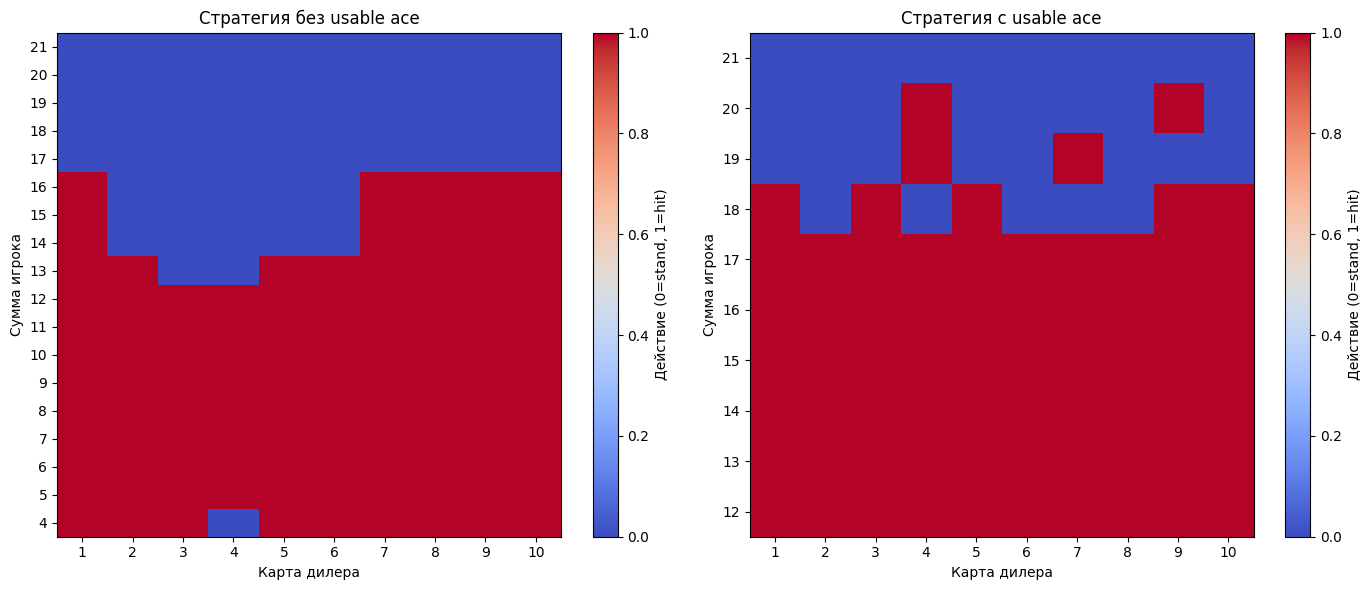


Тестирование обученной стратегии...


Тестирование стратегии: 100%|██████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 19271.73it/s]



Результаты тестирования на 10000 играх:
Выигрышей: 4245 (42.450%)
Проигрышей: 4843 (48.430%)
Ничьих: 912 (9.120%)


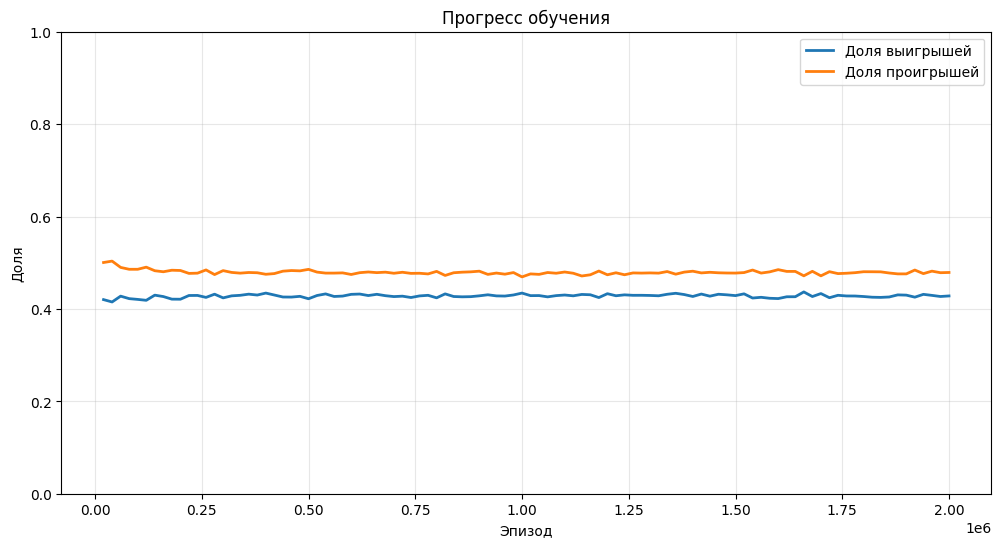

In [4]:
# Создание окружения
env = gym.make('Blackjack-v1', sab=True)

# Конфигурация
config = Config()

# Создание агента
agent = Agent(env, config)

# Обучения агента
print("Начало обучения...")
stats = agent.train()

# Визуализация стратегии
print("\nВизуализация стратегии...")
agent.visualize_strategy()

# Тестирование стратегии
print("\nТестирование обученной стратегии...")
win_rate = agent.test_policy(n_games=10_000)

# Визуализация прогресса обучения
if stats:
    episodes = [s['episode'] for s in stats]
    win_rates = [s['win_rate'] for s in stats]
    loss_rates = [s['loss_rate'] for s in stats]

    plt.figure(figsize=(12, 6))
    plt.plot(episodes, win_rates, label='Доля выигрышей', linewidth=2)
    plt.plot(episodes, loss_rates, label='Доля проигрышей', linewidth=2)
    plt.xlabel('Эпизод')
    plt.ylabel('Доля')
    plt.title('Прогресс обучения')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1)
    plt.show()

env.close()


<p class="task" id="2"></p>

2\. Повторите решение предыдущей задачи, используя алгоритм $\epsilon$-greedy Q-learning. Исследуйте, как гиперпараметры и способ инициализации значений Q-функции влияют на результат.

Cтратегия для выбора действия:
1. Сгенерировать число $p$ из $U(0, 1)$;
2. Если $p < \epsilon$, то выбрать действие случайным образом;
3. В противном случае $a_{t+1}(s_t) = argmax_aQ(s_t, a)$.

Правило обновления Q-функции:
![q-learning](https://wikimedia.org/api/rest_v1/media/math/render/svg/d247db9eaad4bd343e7882ec546bf3847ebd36d8)

- [ ] Проверено на семинаре

Исследование ε-greedy Q-learning для Blackjack
Изучение влияния гиперпараметров и инициализации Q-функции


Эксперимент: Базовый эксперимент
Размеры пространства состояний: (np.int64(32), np.int64(11), np.int64(2))
Количество состояний: 704
Количество возможных действий: 2
Размер Q-таблицы: (32, 11, 2, 2)
Начальное значение ε: 1.0
Начальные значения Q-функции: 0.0


Обучение ε-greedy:   3%|█▋                                                     | 3078/100000 [00:00<00:03, 30777.24it/s]


Эпизод 5000:
  ε: 0.7788
  Доля выигрышей: 29.720% (1486/5000)
  Доля проигрышей: 66.160% (3308/5000)
  Доля ничьих: 4.120% (206/5000)
  Средняя награда: -0.364


Обучение ε-greedy:   9%|█████▏                                                 | 9409/100000 [00:00<00:03, 28638.08it/s]


Эпизод 10000:
  ε: 0.6065
  Доля выигрышей: 32.120% (1606/5000)
  Доля проигрышей: 63.240% (3162/5000)
  Доля ничьих: 4.640% (232/5000)
  Средняя награда: -0.311


...


Эпизод 80000:
  ε: 0.3000
  Доля выигрышей: 38.820% (1941/5000)
  Доля проигрышей: 54.780% (2739/5000)
  Доля ничьих: 6.400% (320/5000)
  Средняя награда: -0.160


Обучение ε-greedy:  91%|████████████████████████████████████████████████▉     | 90526/100000 [00:03<00:00, 25213.73it/s]


Эпизод 85000:
  ε: 0.3000
  Доля выигрышей: 38.260% (1913/5000)
  Доля проигрышей: 55.060% (2753/5000)
  Доля ничьих: 6.680% (334/5000)
  Средняя награда: -0.168

Эпизод 90000:
  ε: 0.3000
  Доля выигрышей: 38.760% (1938/5000)
  Доля проигрышей: 54.260% (2713/5000)
  Доля ничьих: 6.980% (349/5000)
  Средняя награда: -0.155


Обучение ε-greedy: 100%|█████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 22832.17it/s]


Эпизод 95000:
  ε: 0.3000
  Доля выигрышей: 38.220% (1911/5000)
  Доля проигрышей: 54.260% (2713/5000)
  Доля ничьих: 7.520% (376/5000)
  Средняя награда: -0.160

Эпизод 100000:
  ε: 0.3000
  Доля выигрышей: 38.140% (1907/5000)
  Доля проигрышей: 54.540% (2727/5000)
  Доля ничьих: 7.320% (366/5000)
  Средняя награда: -0.164


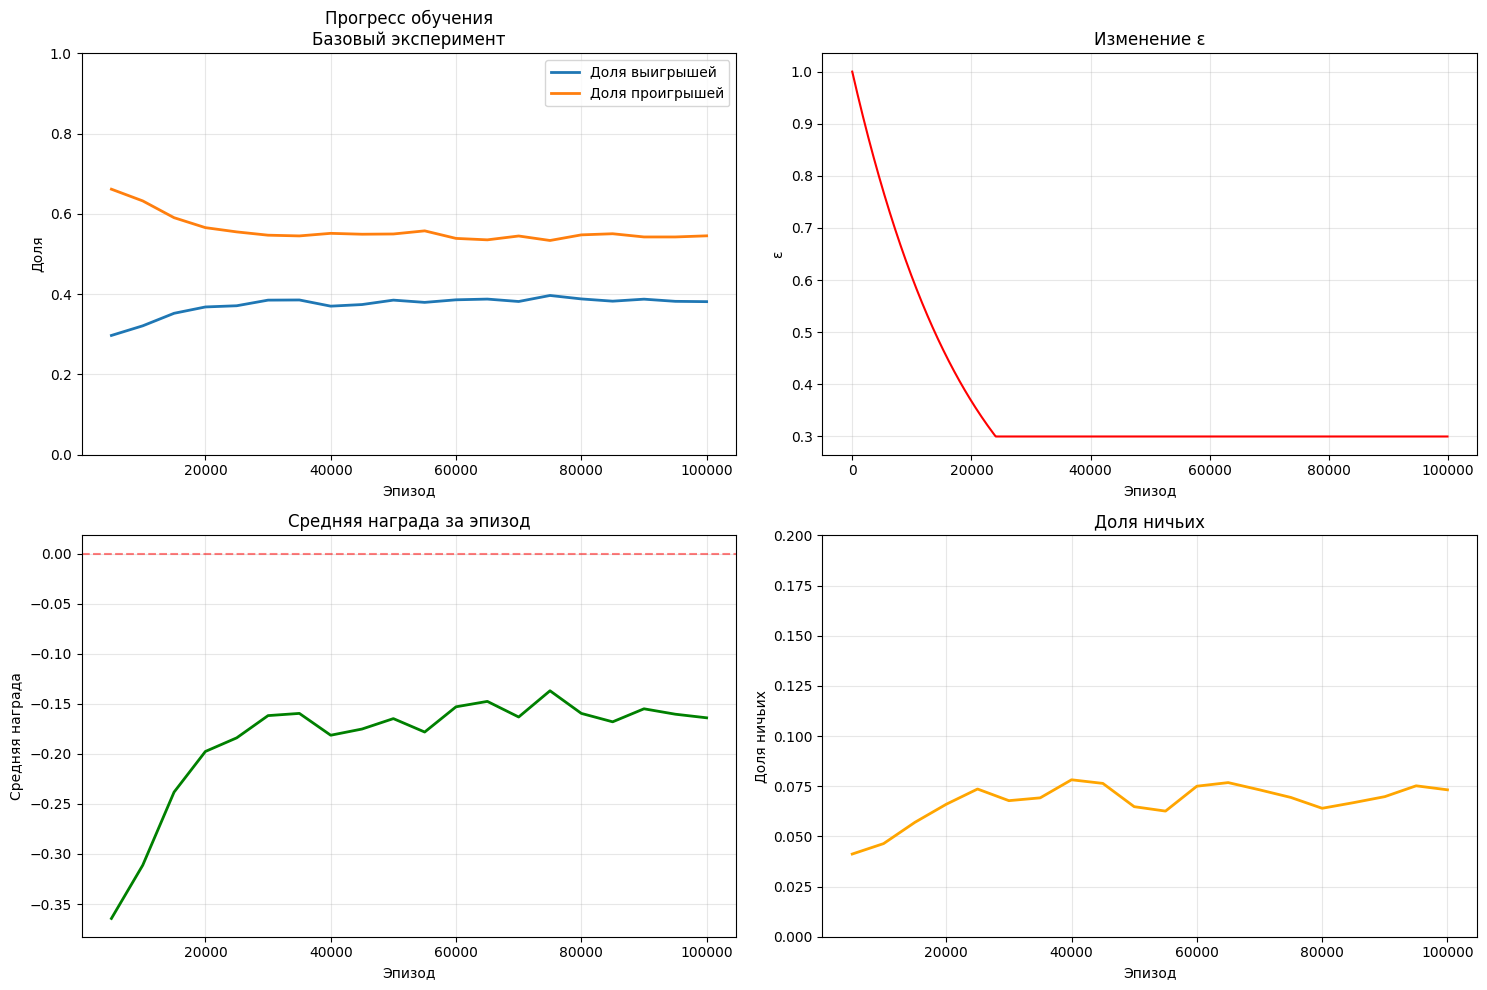

Тестирование стратегии: 100%|██████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 17502.11it/s]



Результаты тестирования на 10000 играх:
Выигрышей: 4322 (43.220%)
Проигрышей: 4892 (48.920%)
Ничьих: 786 (7.860%)

Эксперимент: Q_init = 0.0
Размеры пространства состояний: (np.int64(32), np.int64(11), np.int64(2))
Количество состояний: 704
Количество возможных действий: 2
Размер Q-таблицы: (32, 11, 2, 2)
Начальное значение ε: 1.0
Начальные значения Q-функции: 0.0


Обучение ε-greedy:   3%|█▉                                                     | 3416/100000 [00:00<00:02, 34152.38it/s]


Эпизод 5000:
  ε: 0.7788
  Доля выигрышей: 29.720% (1486/5000)
  Доля проигрышей: 66.160% (3308/5000)
  Доля ничьих: 4.120% (206/5000)
  Средняя награда: -0.364


Обучение ε-greedy:  12%|██████▋                                               | 12423/100000 [00:00<00:03, 25141.71it/s]

...


Эпизод 75000:
  ε: 0.3000
  Доля выигрышей: 39.680% (1984/5000)
  Доля проигрышей: 53.380% (2669/5000)
  Доля ничьих: 6.940% (347/5000)
  Средняя награда: -0.137

Эпизод 80000:
  ε: 0.3000
  Доля выигрышей: 38.820% (1941/5000)
  Доля проигрышей: 54.780% (2739/5000)
  Доля ничьих: 6.400% (320/5000)
  Средняя награда: -0.160


Обучение ε-greedy:  88%|███████████████████████████████████████████████▍      | 87904/100000 [00:03<00:00, 21517.55it/s]


Эпизод 85000:
  ε: 0.3000
  Доля выигрышей: 38.260% (1913/5000)
  Доля проигрышей: 55.060% (2753/5000)
  Доля ничьих: 6.680% (334/5000)
  Средняя награда: -0.168

Эпизод 90000:
  ε: 0.3000
  Доля выигрышей: 38.760% (1938/5000)
  Доля проигрышей: 54.260% (2713/5000)
  Доля ничьих: 6.980% (349/5000)
  Средняя награда: -0.155


Обучение ε-greedy: 100%|█████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 23041.38it/s]


Эпизод 95000:
  ε: 0.3000
  Доля выигрышей: 38.220% (1911/5000)
  Доля проигрышей: 54.260% (2713/5000)
  Доля ничьих: 7.520% (376/5000)
  Средняя награда: -0.160

Эпизод 100000:
  ε: 0.3000
  Доля выигрышей: 38.140% (1907/5000)
  Доля проигрышей: 54.540% (2727/5000)
  Доля ничьих: 7.320% (366/5000)
  Средняя награда: -0.164


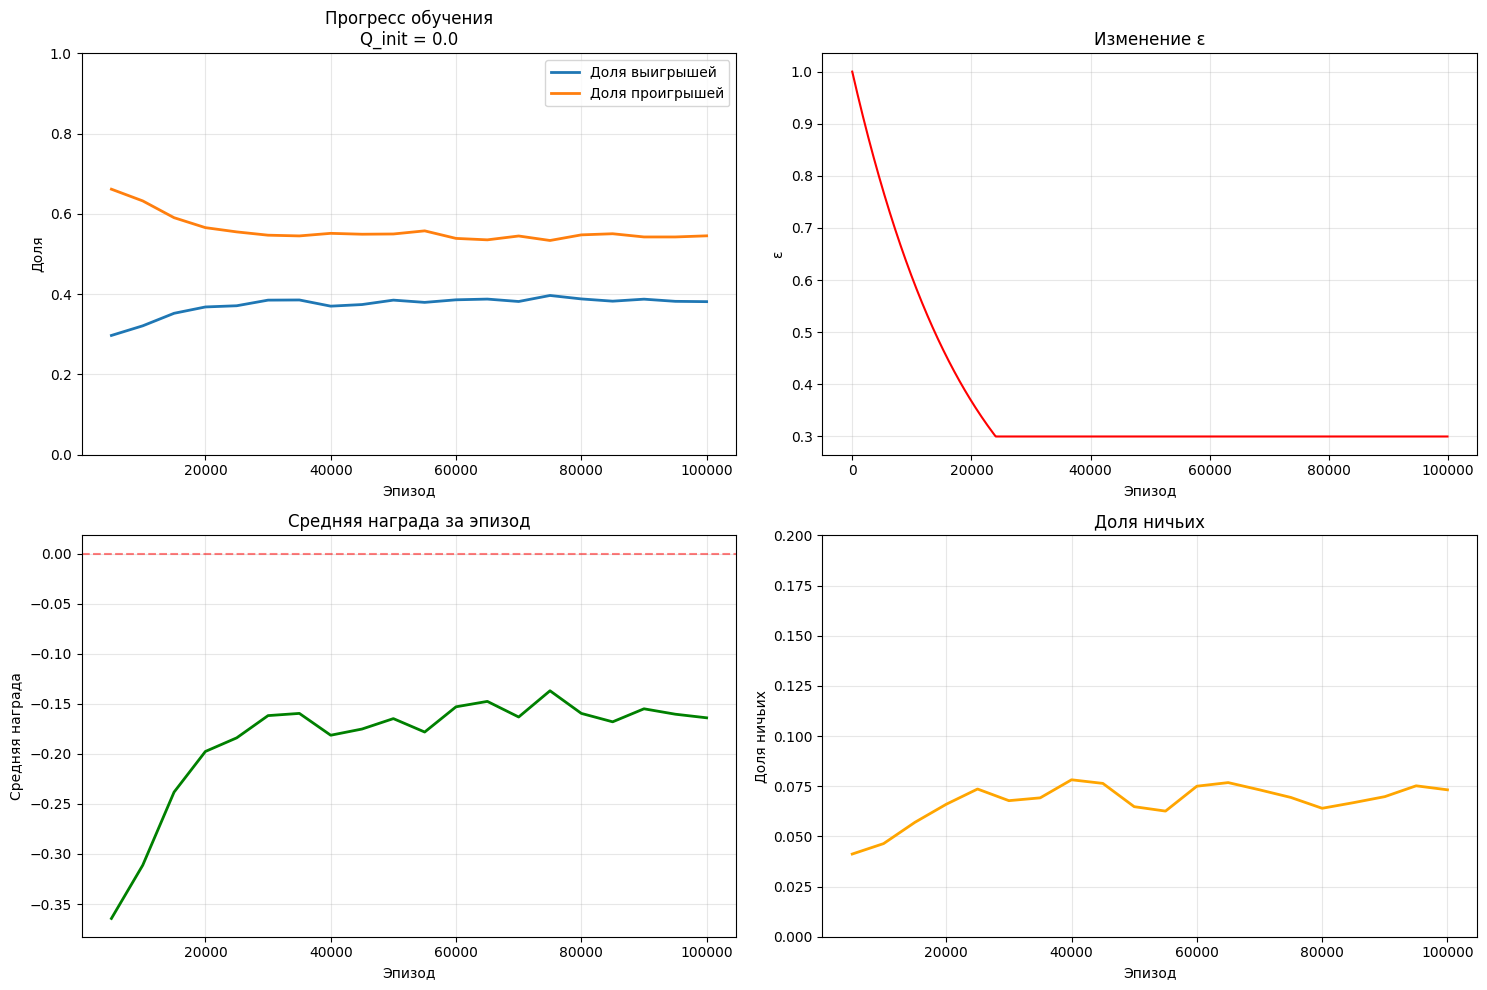

Тестирование стратегии: 100%|██████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 19956.91it/s]



Результаты тестирования на 10000 играх:
Выигрышей: 4322 (43.220%)
Проигрышей: 4892 (48.920%)
Ничьих: 786 (7.860%)

Эксперимент: Q_init = 10.0
Размеры пространства состояний: (np.int64(32), np.int64(11), np.int64(2))
Количество состояний: 704
Количество возможных действий: 2
Размер Q-таблицы: (32, 11, 2, 2)
Начальное значение ε: 1.0
Начальные значения Q-функции: 10.0


Обучение ε-greedy:   3%|█▋                                                     | 3178/100000 [00:00<00:03, 31776.47it/s]


Эпизод 5000:
  ε: 0.7788
  Доля выигрышей: 27.400% (1370/5000)
  Доля проигрышей: 68.320% (3416/5000)
  Доля ничьих: 4.280% (214/5000)
  Средняя награда: -0.409


Обучение ε-greedy:  14%|███████▋                                              | 14340/100000 [00:00<00:03, 22200.23it/s]

...


Эпизод 90000:
  ε: 0.3000
  Доля выигрышей: 33.040% (1652/5000)
  Доля проигрышей: 60.540% (3027/5000)
  Доля ничьих: 6.420% (321/5000)
  Средняя награда: -0.275


Обучение ε-greedy:  99%|█████████████████████████████████████████████████████▌| 99131/100000 [00:04<00:00, 19492.13it/s]


Эпизод 95000:
  ε: 0.3000
  Доля выигрышей: 32.660% (1633/5000)
  Доля проигрышей: 61.360% (3068/5000)
  Доля ничьих: 5.980% (299/5000)
  Средняя награда: -0.287


Обучение ε-greedy: 100%|█████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 20260.33it/s]



Эпизод 100000:
  ε: 0.3000
  Доля выигрышей: 33.880% (1694/5000)
  Доля проигрышей: 60.060% (3003/5000)
  Доля ничьих: 6.060% (303/5000)
  Средняя награда: -0.262


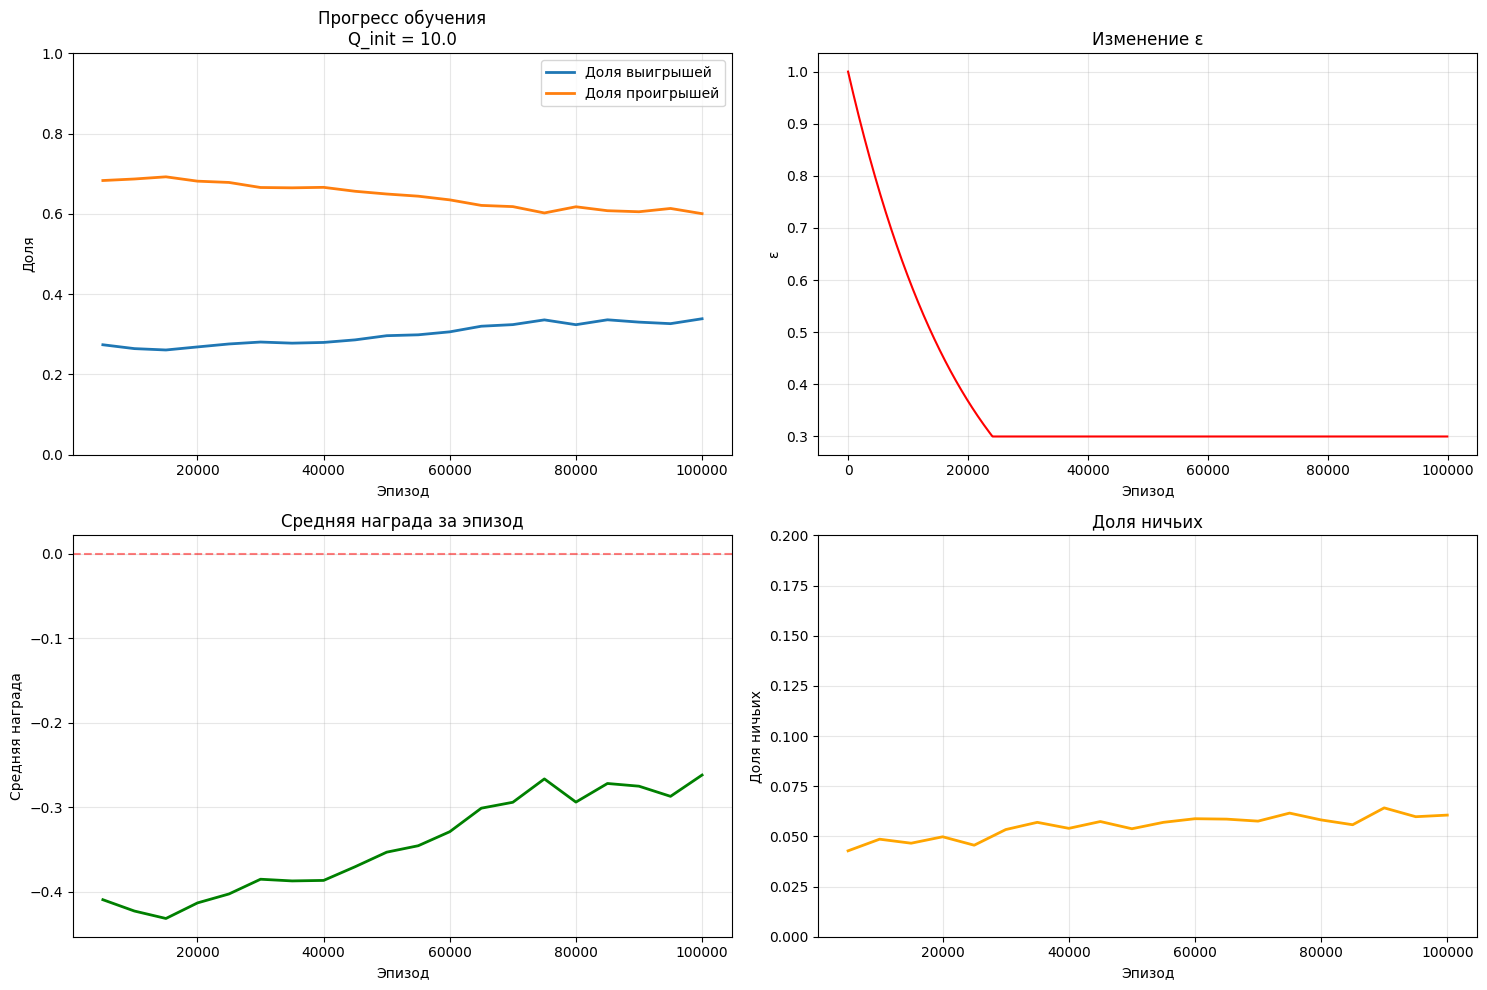

Тестирование стратегии: 100%|██████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 21288.35it/s]



Результаты тестирования на 10000 играх:
Выигрышей: 3751 (37.510%)
Проигрышей: 5473 (54.730%)
Ничьих: 776 (7.760%)

Эксперимент: Q_init = -10.0
Размеры пространства состояний: (np.int64(32), np.int64(11), np.int64(2))
Количество состояний: 704
Количество возможных действий: 2
Размер Q-таблицы: (32, 11, 2, 2)
Начальное значение ε: 1.0
Начальные значения Q-функции: -10.0


Обучение ε-greedy:   9%|████▉                                                  | 8933/100000 [00:00<00:03, 26856.75it/s]


Эпизод 5000:
  ε: 0.7788
  Доля выигрышей: 29.120% (1456/5000)
  Доля проигрышей: 67.020% (3351/5000)
  Доля ничьих: 3.860% (193/5000)
  Средняя награда: -0.379

Эпизод 10000:
  ε: 0.6065
  Доля выигрышей: 31.480% (1574/5000)
  Доля проигрышей: 64.240% (3212/5000)
  Доля ничьих: 4.280% (214/5000)
  Средняя награда: -0.328


Обучение ε-greedy:  19%|██████████▌                                           | 19484/100000 [00:00<00:03, 24030.72it/s]

...


Эпизод 75000:
  ε: 0.3000
  Доля выигрышей: 35.460% (1773/5000)
  Доля проигрышей: 59.980% (2999/5000)
  Доля ничьих: 4.560% (228/5000)
  Средняя награда: -0.245

Эпизод 80000:
  ε: 0.3000
  Доля выигрышей: 35.720% (1786/5000)
  Доля проигрышей: 60.100% (3005/5000)
  Доля ничьих: 4.180% (209/5000)
  Средняя награда: -0.244


Обучение ε-greedy:  91%|█████████████████████████████████████████████████▎    | 91252/100000 [00:03<00:00, 26375.24it/s]


Эпизод 85000:
  ε: 0.3000
  Доля выигрышей: 34.700% (1735/5000)
  Доля проигрышей: 61.140% (3057/5000)
  Доля ничьих: 4.160% (208/5000)
  Средняя награда: -0.264

Эпизод 90000:
  ε: 0.3000
  Доля выигрышей: 35.260% (1763/5000)
  Доля проигрышей: 60.700% (3035/5000)
  Доля ничьих: 4.040% (202/5000)
  Средняя награда: -0.254


Обучение ε-greedy: 100%|█████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 24712.26it/s]


Эпизод 95000:
  ε: 0.3000
  Доля выигрышей: 35.820% (1791/5000)
  Доля проигрышей: 59.860% (2993/5000)
  Доля ничьих: 4.320% (216/5000)
  Средняя награда: -0.240

Эпизод 100000:
  ε: 0.3000
  Доля выигрышей: 34.460% (1723/5000)
  Доля проигрышей: 61.060% (3053/5000)
  Доля ничьих: 4.480% (224/5000)
  Средняя награда: -0.266


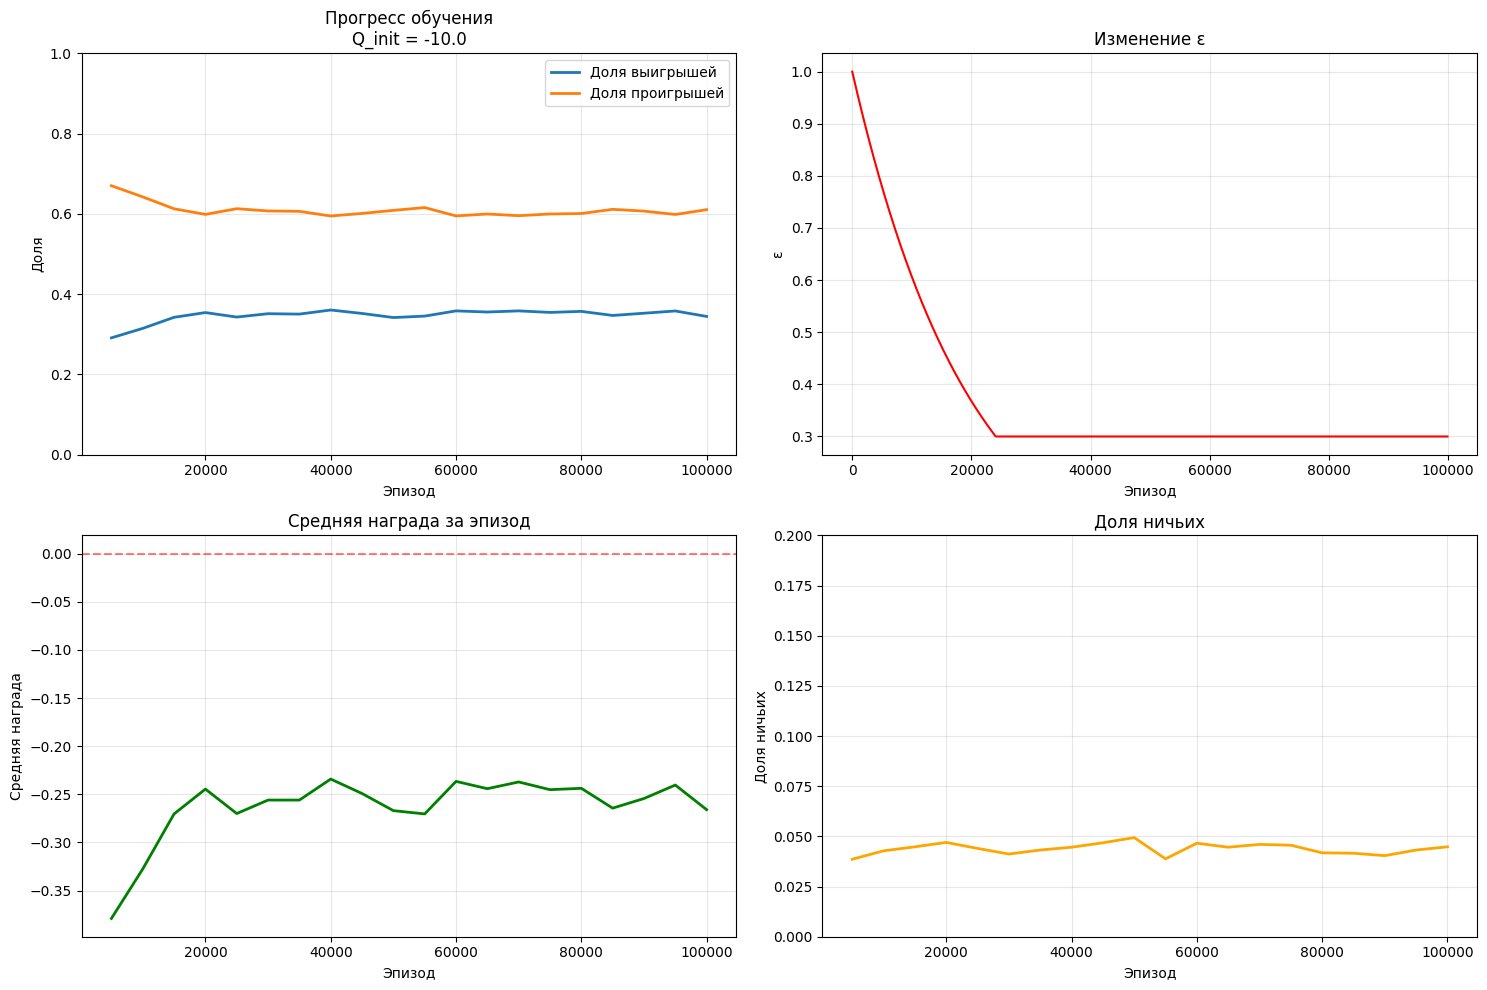

Тестирование стратегии: 100%|██████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 21953.25it/s]



Результаты тестирования на 10000 играх:
Выигрышей: 3606 (36.060%)
Проигрышей: 5931 (59.310%)
Ничьих: 463 (4.630%)

Эксперимент: Q_init = 5.0
Размеры пространства состояний: (np.int64(32), np.int64(11), np.int64(2))
Количество состояний: 704
Количество возможных действий: 2
Размер Q-таблицы: (32, 11, 2, 2)
Начальное значение ε: 1.0
Начальные значения Q-функции: 5.0


Обучение ε-greedy:   3%|█▍                                                     | 2650/100000 [00:00<00:03, 26495.79it/s]


Эпизод 5000:
  ε: 0.7788
  Доля выигрышей: 27.800% (1390/5000)
  Доля проигрышей: 67.880% (3394/5000)
  Доля ничьих: 4.320% (216/5000)
  Средняя награда: -0.401


Обучение ε-greedy:   9%|████▉                                                  | 8937/100000 [00:00<00:03, 28021.90it/s]

...


Эпизод 90000:
  ε: 0.3000
  Доля выигрышей: 35.020% (1751/5000)
  Доля проигрышей: 58.280% (2914/5000)
  Доля ничьих: 6.700% (335/5000)
  Средняя награда: -0.233


Обучение ε-greedy:  99%|█████████████████████████████████████████████████████▎| 98746/100000 [00:04<00:00, 18622.57it/s]


Эпизод 95000:
  ε: 0.3000
  Доля выигрышей: 33.840% (1692/5000)
  Доля проигрышей: 59.580% (2979/5000)
  Доля ничьих: 6.580% (329/5000)
  Средняя награда: -0.257


Обучение ε-greedy: 100%|█████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 21096.58it/s]



Эпизод 100000:
  ε: 0.3000
  Доля выигрышей: 35.920% (1796/5000)
  Доля проигрышей: 57.200% (2860/5000)
  Доля ничьих: 6.880% (344/5000)
  Средняя награда: -0.213


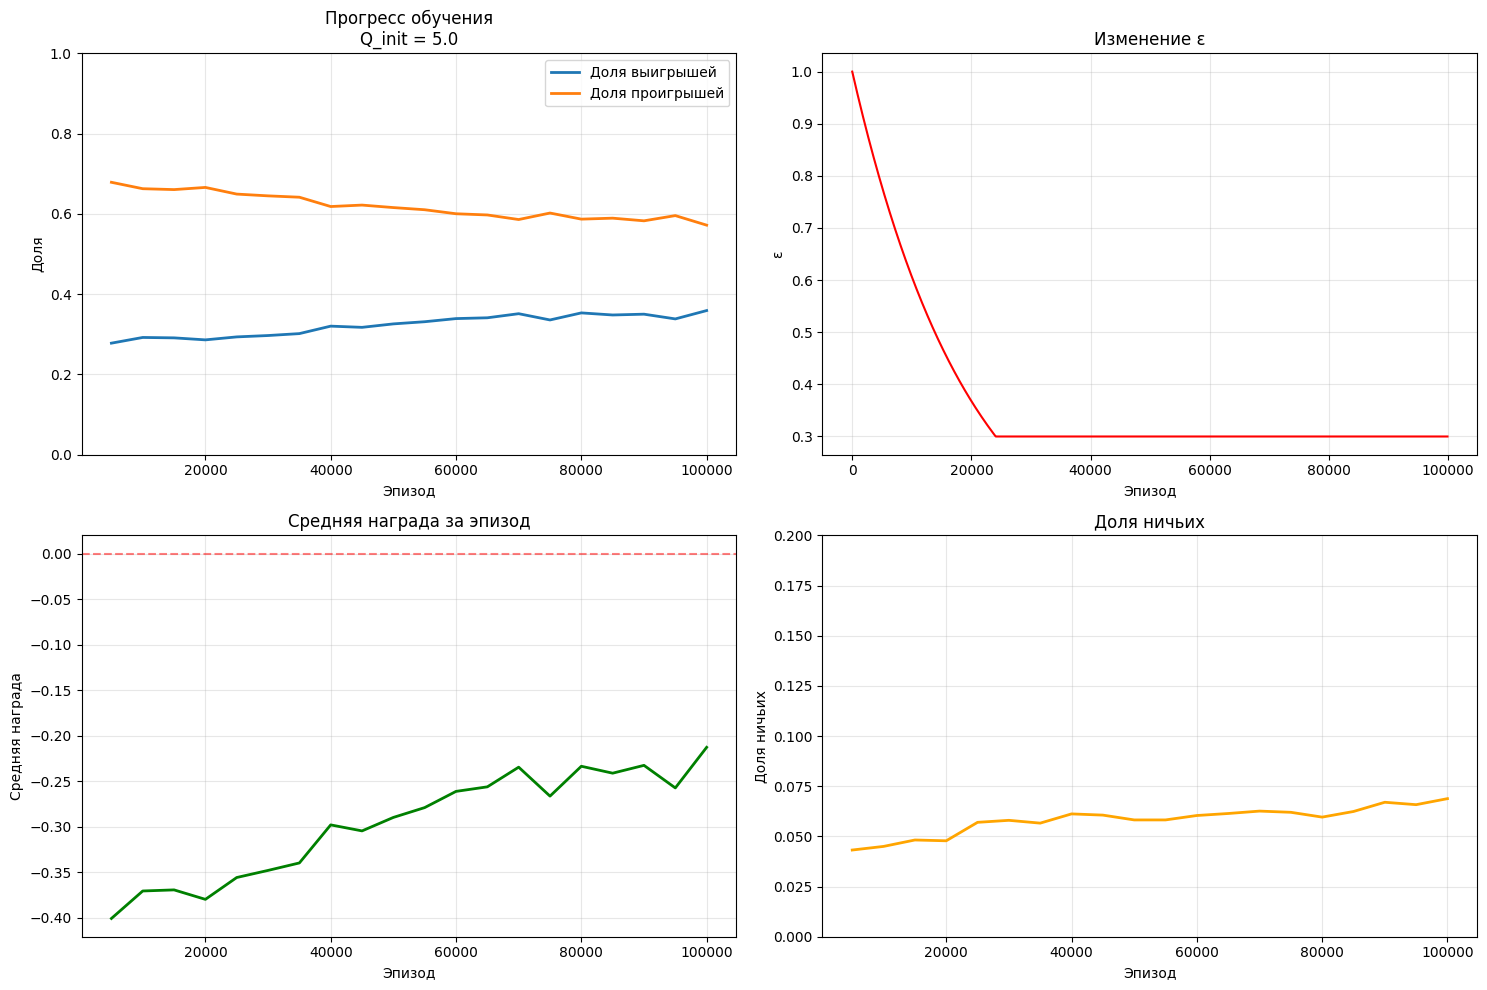

Тестирование стратегии: 100%|██████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 17917.92it/s]



Результаты тестирования на 10000 играх:
Выигрышей: 3822 (38.220%)
Проигрышей: 5408 (54.080%)
Ничьих: 770 (7.700%)

Эксперимент: LR = 0.001
Размеры пространства состояний: (np.int64(32), np.int64(11), np.int64(2))
Количество состояний: 704
Количество возможных действий: 2
Размер Q-таблицы: (32, 11, 2, 2)
Начальное значение ε: 1.0
Начальные значения Q-функции: 0.0


Обучение ε-greedy:   5%|██▊                                                    | 5048/100000 [00:00<00:03, 25403.98it/s]


Эпизод 5000:
  ε: 0.7788
  Доля выигрышей: 29.700% (1485/5000)
  Доля проигрышей: 66.180% (3309/5000)
  Доля ничьих: 4.120% (206/5000)
  Средняя награда: -0.365


Обучение ε-greedy:  15%|████████                                              | 15007/100000 [00:00<00:03, 24181.51it/s]

...


Эпизод 90000:
  ε: 0.3000
  Доля выигрышей: 38.640% (1932/5000)
  Доля проигрышей: 54.300% (2715/5000)
  Доля ничьих: 7.060% (353/5000)
  Средняя награда: -0.157


Обучение ε-greedy:  98%|████████████████████████████████████████████████████▋ | 97627/100000 [00:04<00:00, 19030.84it/s]


Эпизод 95000:
  ε: 0.3000
  Доля выигрышей: 37.700% (1885/5000)
  Доля проигрышей: 55.040% (2752/5000)
  Доля ничьих: 7.260% (363/5000)
  Средняя награда: -0.173


Обучение ε-greedy: 100%|█████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 21759.36it/s]



Эпизод 100000:
  ε: 0.3000
  Доля выигрышей: 38.300% (1915/5000)
  Доля проигрышей: 54.940% (2747/5000)
  Доля ничьих: 6.760% (338/5000)
  Средняя награда: -0.166


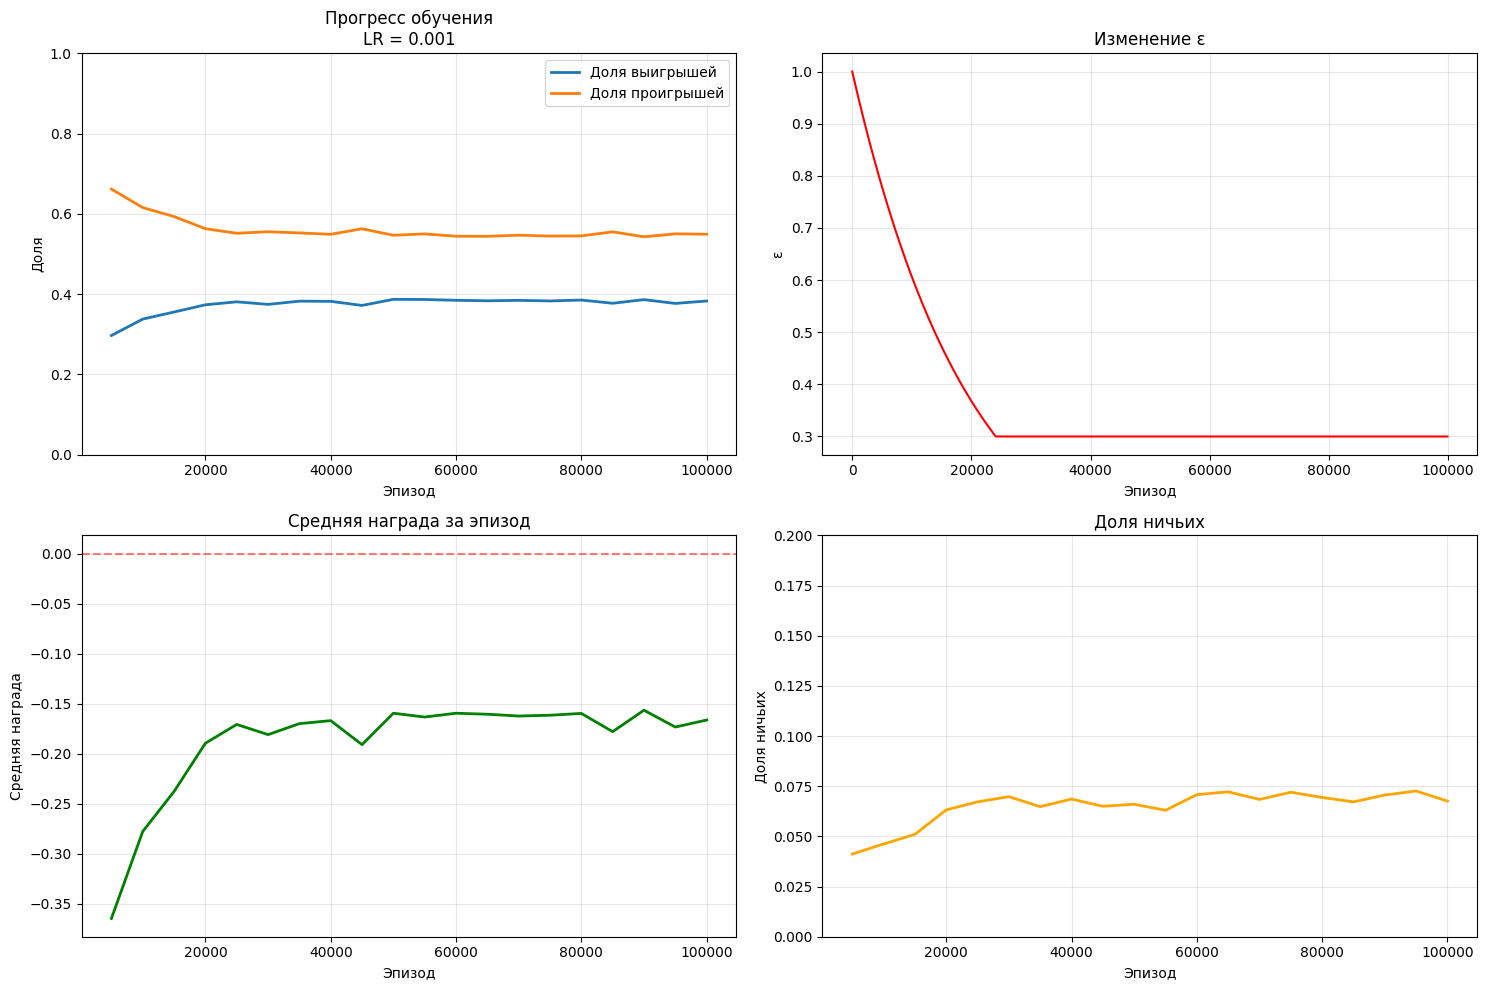

Тестирование стратегии: 100%|██████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 21673.67it/s]



Результаты тестирования на 10000 играх:
Выигрышей: 4249 (42.490%)
Проигрышей: 4956 (49.560%)
Ничьих: 795 (7.950%)

Эксперимент: LR = 0.01
Размеры пространства состояний: (np.int64(32), np.int64(11), np.int64(2))
Количество состояний: 704
Количество возможных действий: 2
Размер Q-таблицы: (32, 11, 2, 2)
Начальное значение ε: 1.0
Начальные значения Q-функции: 0.0


Обучение ε-greedy:   2%|█▎                                                     | 2320/100000 [00:00<00:04, 23194.88it/s]


Эпизод 5000:
  ε: 0.7788
  Доля выигрышей: 29.700% (1485/5000)
  Доля проигрышей: 66.180% (3309/5000)
  Доля ничьих: 4.120% (206/5000)
  Средняя награда: -0.365


Обучение ε-greedy:   9%|████▋                                                  | 8567/100000 [00:00<00:03, 29126.82it/s]

...


Эпизод 85000:
  ε: 0.3000
  Доля выигрышей: 37.880% (1894/5000)
  Доля проигрышей: 55.280% (2764/5000)
  Доля ничьих: 6.840% (342/5000)
  Средняя награда: -0.174

Эпизод 90000:
  ε: 0.3000
  Доля выигрышей: 39.680% (1984/5000)
  Доля проигрышей: 52.780% (2639/5000)
  Доля ничьих: 7.540% (377/5000)
  Средняя награда: -0.131


Обучение ε-greedy:  98%|█████████████████████████████████████████████████████▏| 98392/100000 [00:04<00:00, 19750.87it/s]


Эпизод 95000:
  ε: 0.3000
  Доля выигрышей: 38.240% (1912/5000)
  Доля проигрышей: 53.920% (2696/5000)
  Доля ничьих: 7.840% (392/5000)
  Средняя награда: -0.157


Обучение ε-greedy: 100%|█████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 22440.22it/s]



Эпизод 100000:
  ε: 0.3000
  Доля выигрышей: 38.640% (1932/5000)
  Доля проигрышей: 53.740% (2687/5000)
  Доля ничьих: 7.620% (381/5000)
  Средняя награда: -0.151


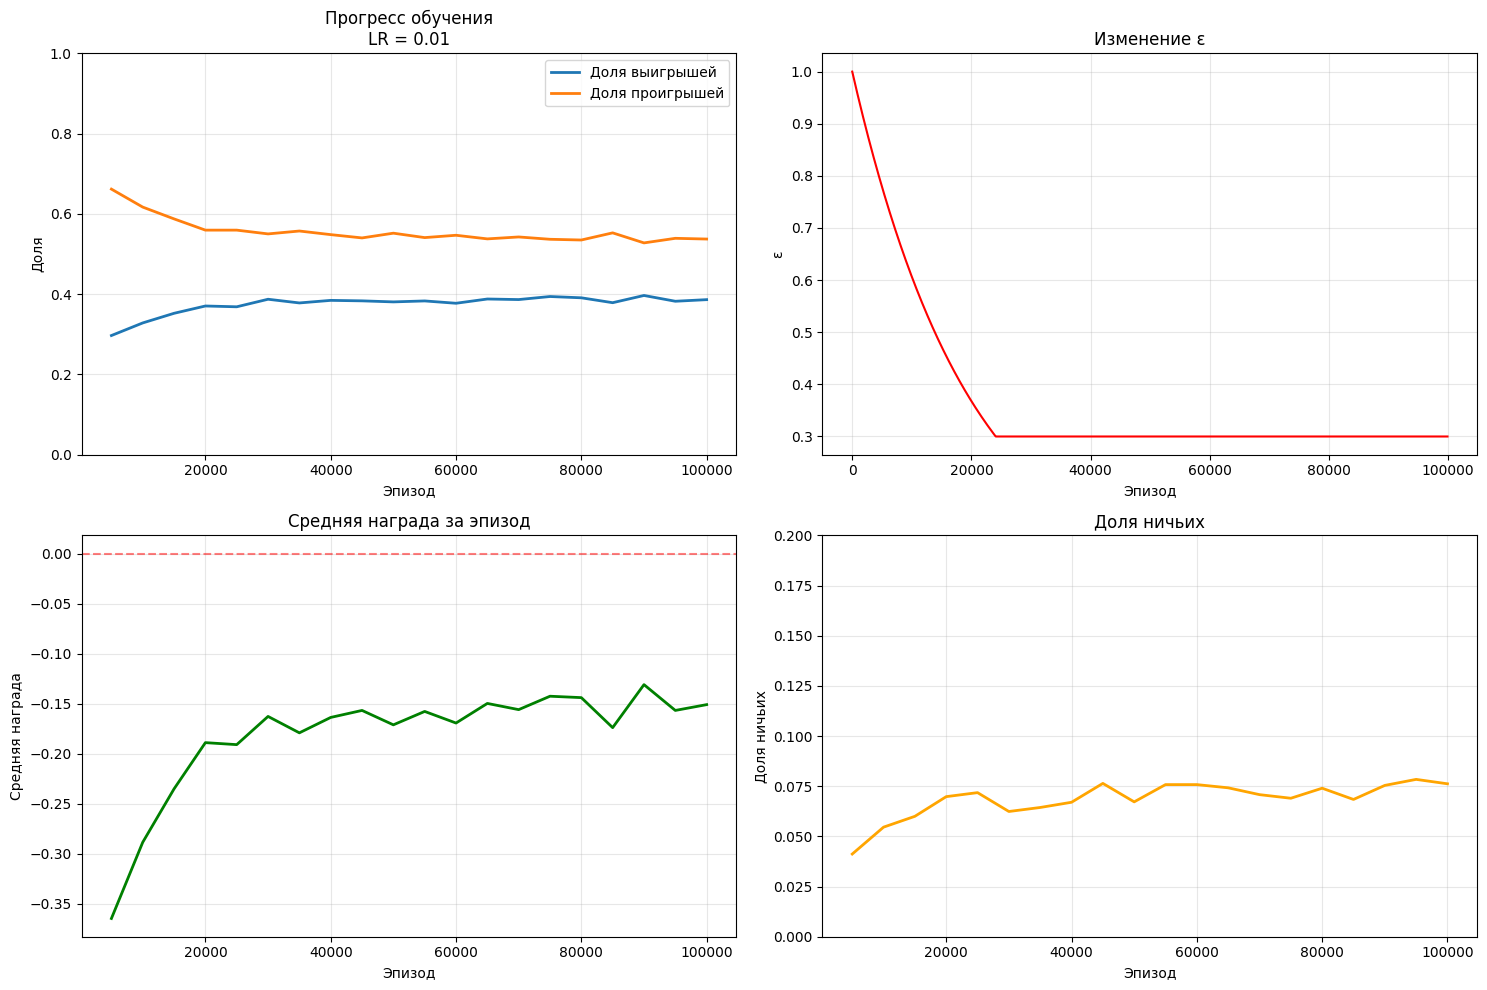

Тестирование стратегии: 100%|██████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 19144.27it/s]



Результаты тестирования на 10000 играх:
Выигрышей: 4240 (42.400%)
Проигрышей: 4884 (48.840%)
Ничьих: 876 (8.760%)

Эксперимент: LR = 0.05
Размеры пространства состояний: (np.int64(32), np.int64(11), np.int64(2))
Количество состояний: 704
Количество возможных действий: 2
Размер Q-таблицы: (32, 11, 2, 2)
Начальное значение ε: 1.0
Начальные значения Q-функции: 0.0


Обучение ε-greedy:  10%|█████▍                                                 | 9871/100000 [00:00<00:03, 25267.68it/s]


Эпизод 5000:
  ε: 0.7788
  Доля выигрышей: 29.360% (1468/5000)
  Доля проигрышей: 66.480% (3324/5000)
  Доля ничьих: 4.160% (208/5000)
  Средняя награда: -0.371

Эпизод 10000:
  ε: 0.6065
  Доля выигрышей: 33.040% (1652/5000)
  Доля проигрышей: 62.100% (3105/5000)
  Доля ничьих: 4.860% (243/5000)
  Средняя награда: -0.291


Обучение ε-greedy:  18%|█████████▌                                            | 17752/100000 [00:00<00:03, 25158.32it/s]

...


Эпизод 85000:
  ε: 0.3000
  Доля выигрышей: 38.140% (1907/5000)
  Доля проигрышей: 54.420% (2721/5000)
  Доля ничьих: 7.440% (372/5000)
  Средняя награда: -0.163


Обучение ε-greedy:  95%|███████████████████████████████████████████████████▍  | 95253/100000 [00:04<00:00, 22789.19it/s]


Эпизод 90000:
  ε: 0.3000
  Доля выигрышей: 37.760% (1888/5000)
  Доля проигрышей: 55.340% (2767/5000)
  Доля ничьих: 6.900% (345/5000)
  Средняя награда: -0.176

Эпизод 95000:
  ε: 0.3000
  Доля выигрышей: 37.160% (1858/5000)
  Доля проигрышей: 54.500% (2725/5000)
  Доля ничьих: 8.340% (417/5000)
  Средняя награда: -0.173


Обучение ε-greedy: 100%|█████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 21684.67it/s]



Эпизод 100000:
  ε: 0.3000
  Доля выигрышей: 37.660% (1883/5000)
  Доля проигрышей: 54.920% (2746/5000)
  Доля ничьих: 7.420% (371/5000)
  Средняя награда: -0.173


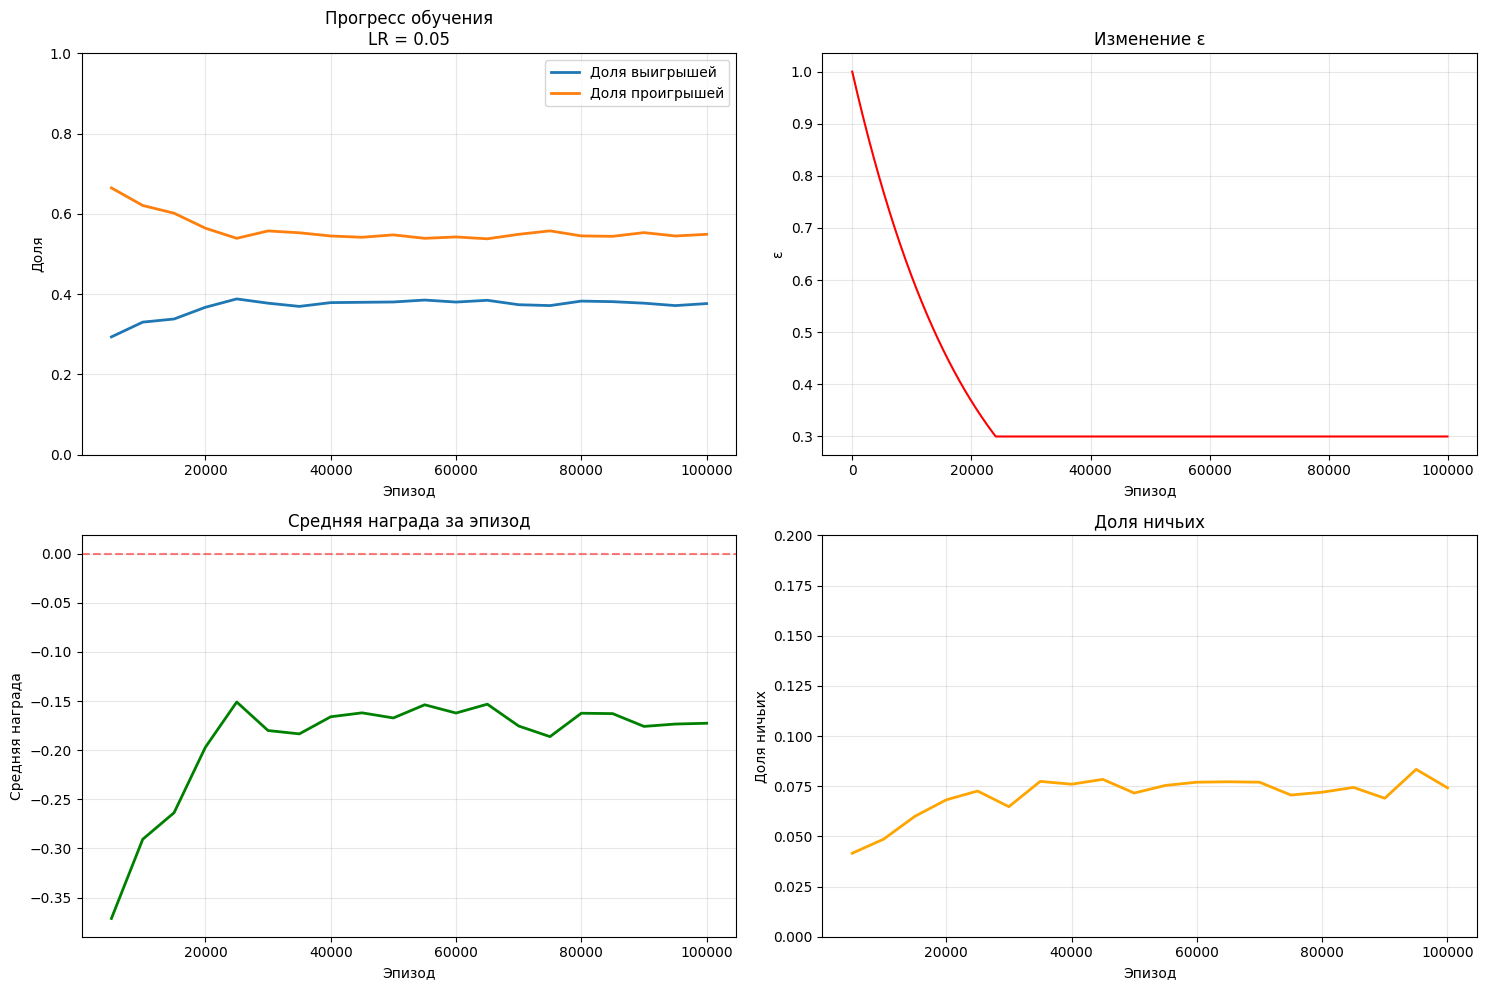

Тестирование стратегии: 100%|██████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 18387.23it/s]



Результаты тестирования на 10000 играх:
Выигрышей: 4238 (42.380%)
Проигрышей: 4867 (48.670%)
Ничьих: 895 (8.950%)

Эксперимент: Постоянное ε=0.1
Размеры пространства состояний: (np.int64(32), np.int64(11), np.int64(2))
Количество состояний: 704
Количество возможных действий: 2
Размер Q-таблицы: (32, 11, 2, 2)
Начальное значение ε: 0.1
Начальные значения Q-функции: 0.0


Обучение ε-greedy:   9%|████▊                                                  | 8805/100000 [00:00<00:04, 18338.20it/s]


Эпизод 5000:
  ε: 0.1000
  Доля выигрышей: 37.000% (1850/5000)
  Доля проигрышей: 55.640% (2782/5000)
  Доля ничьих: 7.360% (368/5000)
  Средняя награда: -0.186


Обучение ε-greedy:  14%|███████▎                                              | 13510/100000 [00:00<00:04, 19954.96it/s]

...


Эпизод 90000:
  ε: 0.1000
  Доля выигрышей: 40.380% (2019/5000)
  Доля проигрышей: 51.960% (2598/5000)
  Доля ничьих: 7.660% (383/5000)
  Средняя награда: -0.116


Обучение ε-greedy:  97%|████████████████████████████████████████████████████▌ | 97377/100000 [00:04<00:00, 20390.64it/s]


Эпизод 95000:
  ε: 0.1000
  Доля выигрышей: 40.800% (2040/5000)
  Доля проигрышей: 51.140% (2557/5000)
  Доля ничьих: 8.060% (403/5000)
  Средняя награда: -0.103


Обучение ε-greedy: 100%|█████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 20940.95it/s]



Эпизод 100000:
  ε: 0.1000
  Доля выигрышей: 41.920% (2096/5000)
  Доля проигрышей: 49.340% (2467/5000)
  Доля ничьих: 8.740% (437/5000)
  Средняя награда: -0.074


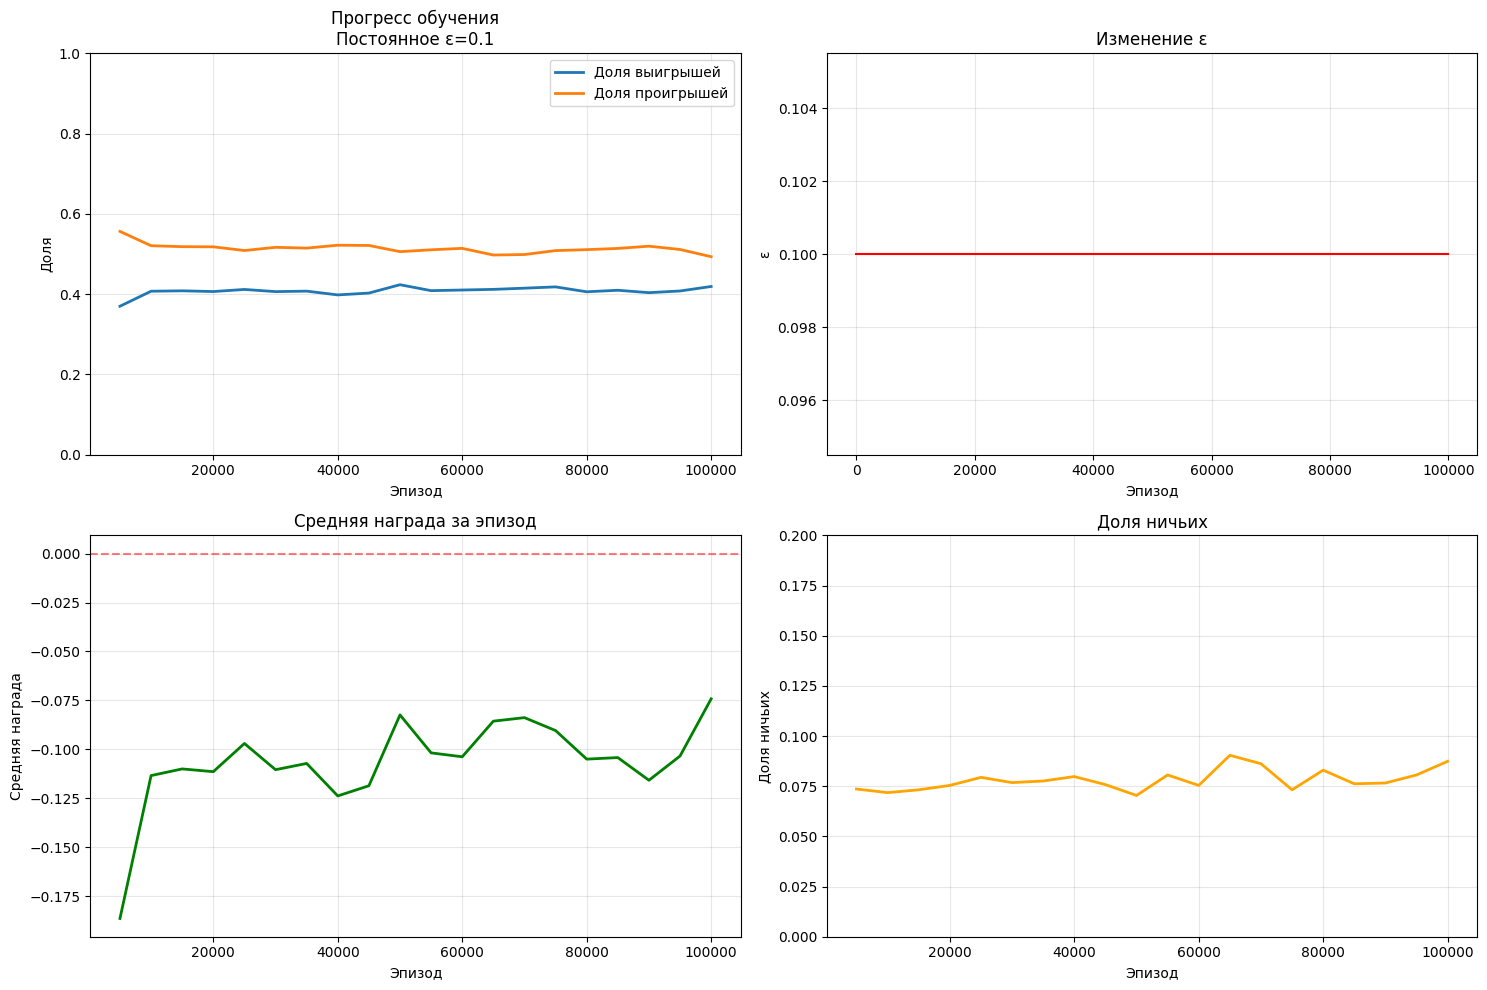

Тестирование стратегии: 100%|██████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 20599.31it/s]



Результаты тестирования на 10000 играх:
Выигрышей: 4240 (42.400%)
Проигрышей: 4908 (49.080%)
Ничьих: 852 (8.520%)

Эксперимент: Уменьшение ε до 0.01
Размеры пространства состояний: (np.int64(32), np.int64(11), np.int64(2))
Количество состояний: 704
Количество возможных действий: 2
Размер Q-таблицы: (32, 11, 2, 2)
Начальное значение ε: 0.5
Начальные значения Q-функции: 0.0


Обучение ε-greedy:   8%|████▏                                                  | 7706/100000 [00:00<00:03, 26031.63it/s]


Эпизод 5000:
  ε: 0.3894
  Доля выигрышей: 34.440% (1722/5000)
  Доля проигрышей: 59.640% (2982/5000)
  Доля ничьих: 5.920% (296/5000)
  Средняя награда: -0.252


Обучение ε-greedy:  13%|███████▏                                              | 13316/100000 [00:00<00:03, 23919.84it/s]

...


Эпизод 85000:
  ε: 0.0100
  Доля выигрышей: 43.300% (2165/5000)
  Доля проигрышей: 49.260% (2463/5000)
  Доля ничьих: 7.440% (372/5000)
  Средняя награда: -0.060

Эпизод 90000:
  ε: 0.0100
  Доля выигрышей: 42.460% (2123/5000)
  Доля проигрышей: 49.280% (2464/5000)
  Доля ничьих: 8.260% (413/5000)
  Средняя награда: -0.068


Обучение ε-greedy:  98%|█████████████████████████████████████████████████████ | 98294/100000 [00:04<00:00, 21492.31it/s]


Эпизод 95000:
  ε: 0.0100
  Доля выигрышей: 41.920% (2096/5000)
  Доля проигрышей: 49.960% (2498/5000)
  Доля ничьих: 8.120% (406/5000)
  Средняя награда: -0.080


Обучение ε-greedy: 100%|█████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 21482.81it/s]



Эпизод 100000:
  ε: 0.0100
  Доля выигрышей: 42.640% (2132/5000)
  Доля проигрышей: 48.400% (2420/5000)
  Доля ничьих: 8.960% (448/5000)
  Средняя награда: -0.058


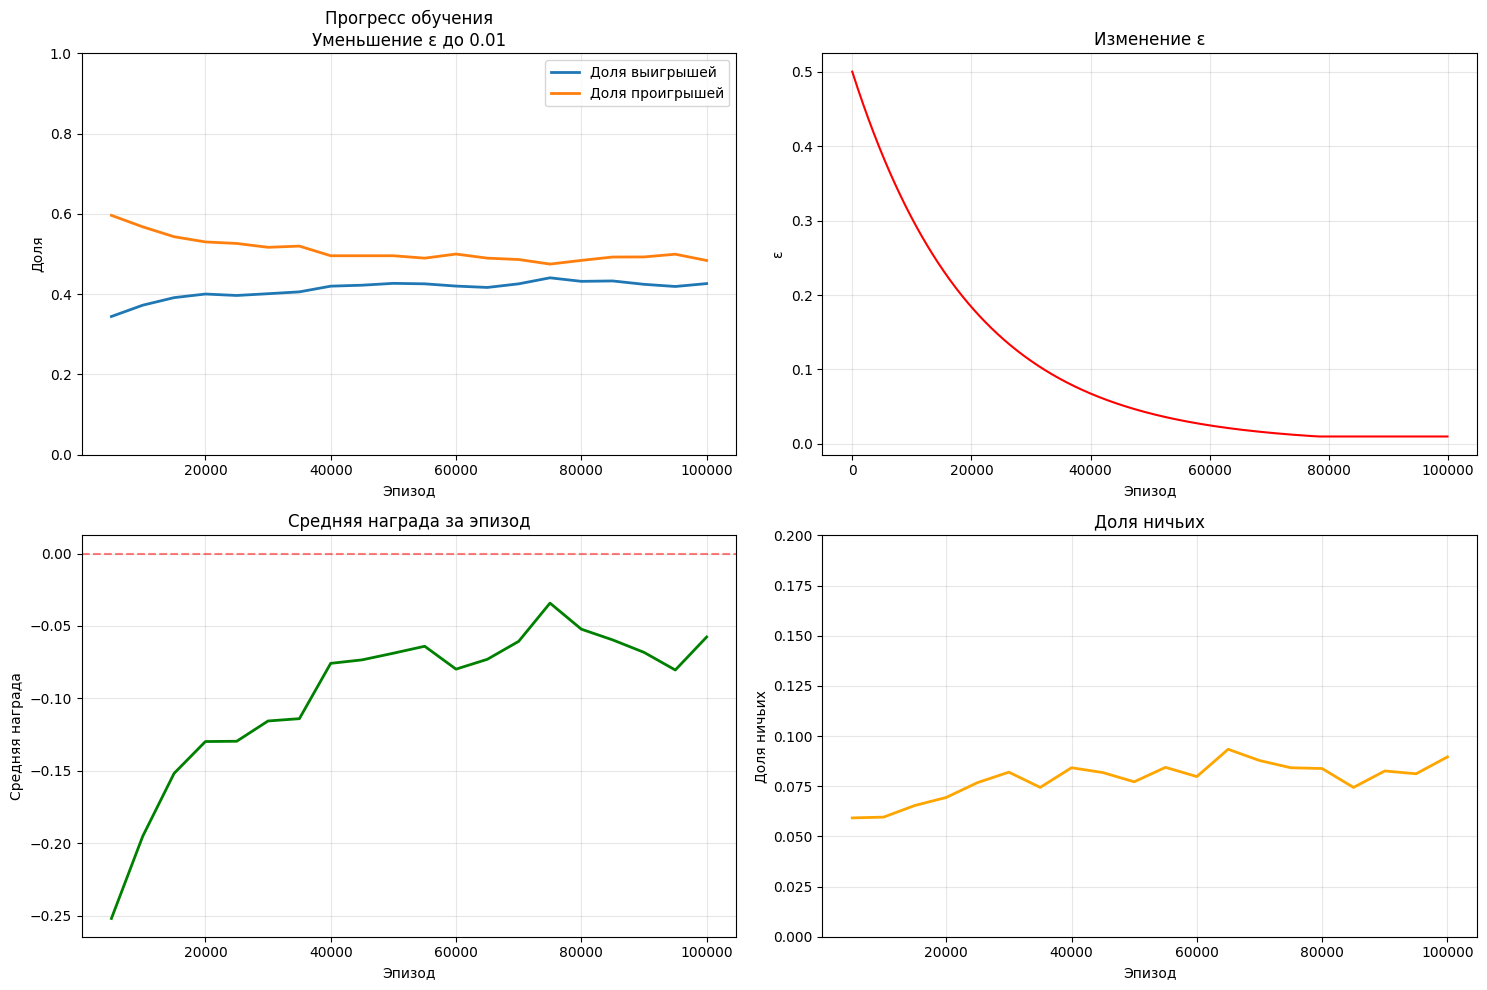

Тестирование стратегии: 100%|██████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 21328.73it/s]



Результаты тестирования на 10000 играх:
Выигрышей: 4208 (42.080%)
Проигрышей: 4921 (49.210%)
Ничьих: 871 (8.710%)

Эксперимент: Discount = 0.9
Размеры пространства состояний: (np.int64(32), np.int64(11), np.int64(2))
Количество состояний: 704
Количество возможных действий: 2
Размер Q-таблицы: (32, 11, 2, 2)
Начальное значение ε: 1.0
Начальные значения Q-функции: 0.0


Обучение ε-greedy:   3%|█▊                                                     | 3315/100000 [00:00<00:02, 33147.98it/s]


Эпизод 5000:
  ε: 0.7788
  Доля выигрышей: 29.320% (1466/5000)
  Доля проигрышей: 66.580% (3329/5000)
  Доля ничьих: 4.100% (205/5000)
  Средняя награда: -0.373


Обучение ε-greedy:  14%|███████▊                                              | 14419/100000 [00:00<00:03, 23213.78it/s]

...


Эпизод 85000:
  ε: 0.3000
  Доля выигрышей: 38.180% (1909/5000)
  Доля проигрышей: 55.100% (2755/5000)
  Доля ничьих: 6.720% (336/5000)
  Средняя награда: -0.169

Эпизод 90000:
  ε: 0.3000
  Доля выигрышей: 38.980% (1949/5000)
  Доля проигрышей: 53.620% (2681/5000)
  Доля ничьих: 7.400% (370/5000)
  Средняя награда: -0.146


Обучение ε-greedy: 100%|█████████████████████████████████████████████████████▊| 99753/100000 [00:04<00:00, 25086.27it/s]


Эпизод 95000:
  ε: 0.3000
  Доля выигрышей: 38.160% (1908/5000)
  Доля проигрышей: 54.180% (2709/5000)
  Доля ничьих: 7.660% (383/5000)
  Средняя награда: -0.160


Обучение ε-greedy: 100%|█████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 23891.23it/s]



Эпизод 100000:
  ε: 0.3000
  Доля выигрышей: 38.020% (1901/5000)
  Доля проигрышей: 54.040% (2702/5000)
  Доля ничьих: 7.940% (397/5000)
  Средняя награда: -0.160


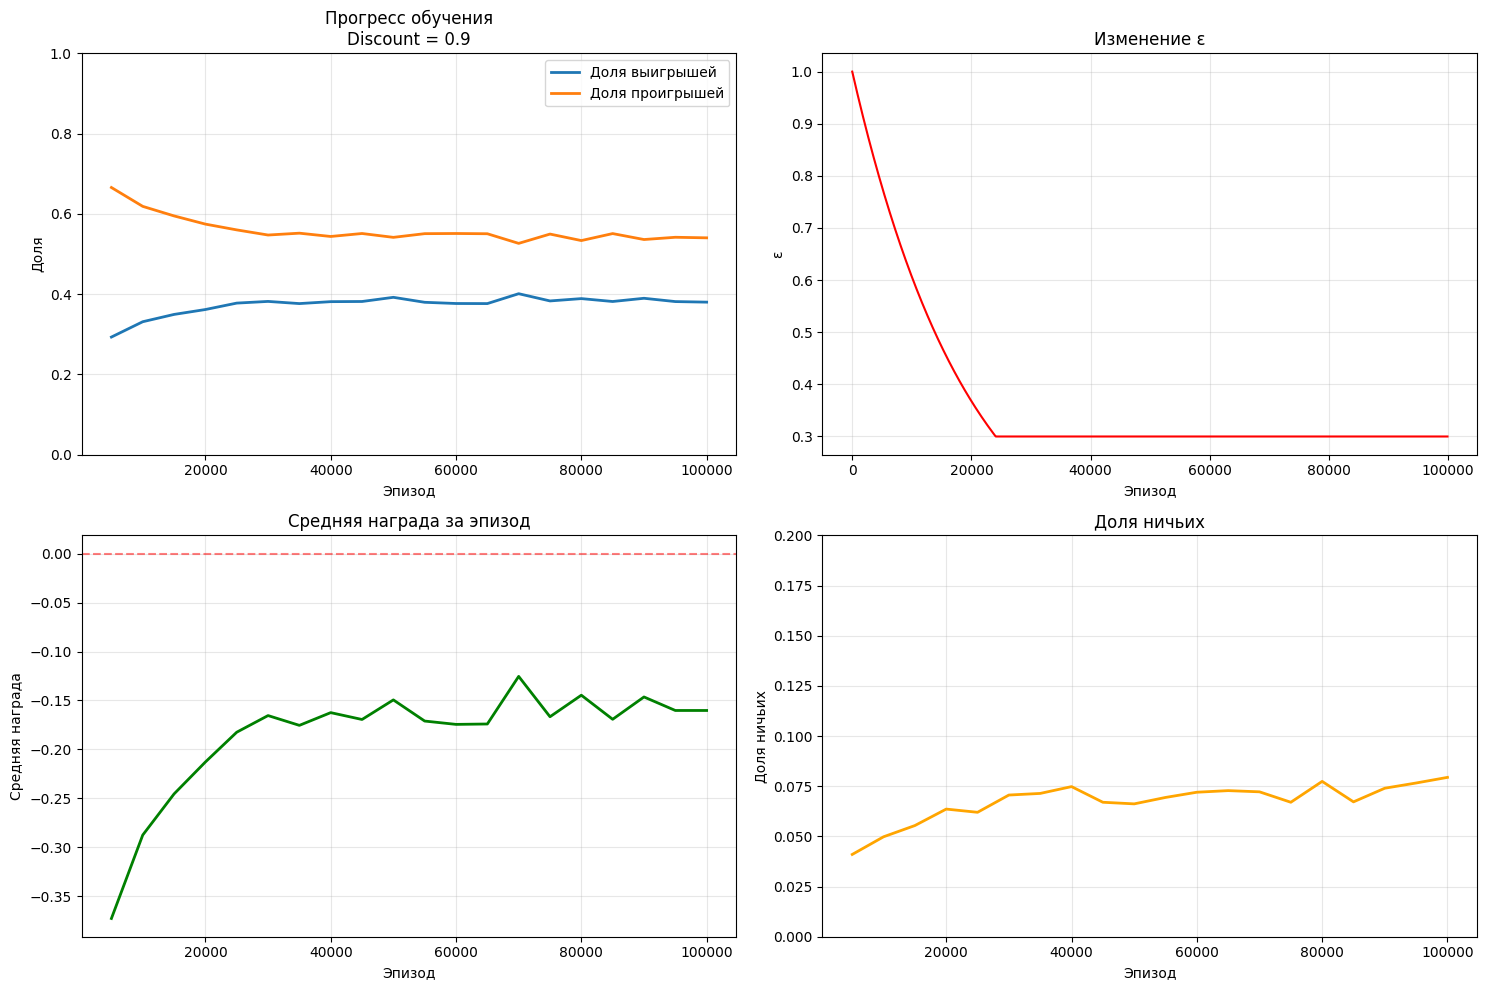

Тестирование стратегии: 100%|██████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 21443.75it/s]



Результаты тестирования на 10000 играх:
Выигрышей: 4296 (42.960%)
Проигрышей: 4832 (48.320%)
Ничьих: 872 (8.720%)

Эксперимент: Discount = 0.95
Размеры пространства состояний: (np.int64(32), np.int64(11), np.int64(2))
Количество состояний: 704
Количество возможных действий: 2
Размер Q-таблицы: (32, 11, 2, 2)
Начальное значение ε: 1.0
Начальные значения Q-функции: 0.0


Обучение ε-greedy:   9%|████▉                                                  | 8967/100000 [00:00<00:03, 25062.44it/s]


Эпизод 5000:
  ε: 0.7788
  Доля выигрышей: 29.720% (1486/5000)
  Доля проигрышей: 66.160% (3308/5000)
  Доля ничьих: 4.120% (206/5000)
  Средняя награда: -0.364


Обучение ε-greedy:  15%|███████▉                                              | 14618/100000 [00:00<00:03, 22419.79it/s]

...


Эпизод 80000:
  ε: 0.3000
  Доля выигрышей: 38.820% (1941/5000)
  Доля проигрышей: 54.780% (2739/5000)
  Доля ничьих: 6.400% (320/5000)
  Средняя награда: -0.160

Эпизод 85000:
  ε: 0.3000
  Доля выигрышей: 38.260% (1913/5000)
  Доля проигрышей: 55.060% (2753/5000)
  Доля ничьих: 6.680% (334/5000)
  Средняя награда: -0.168


Обучение ε-greedy:  94%|██████████████████████████████████████████████████▊   | 94108/100000 [00:03<00:00, 24509.98it/s]


Эпизод 90000:
  ε: 0.3000
  Доля выигрышей: 38.760% (1938/5000)
  Доля проигрышей: 54.260% (2713/5000)
  Доля ничьих: 6.980% (349/5000)
  Средняя награда: -0.155


Обучение ε-greedy: 100%|█████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 23405.95it/s]


Эпизод 95000:
  ε: 0.3000
  Доля выигрышей: 38.220% (1911/5000)
  Доля проигрышей: 54.260% (2713/5000)
  Доля ничьих: 7.520% (376/5000)
  Средняя награда: -0.160

Эпизод 100000:
  ε: 0.3000
  Доля выигрышей: 38.140% (1907/5000)
  Доля проигрышей: 54.540% (2727/5000)
  Доля ничьих: 7.320% (366/5000)
  Средняя награда: -0.164


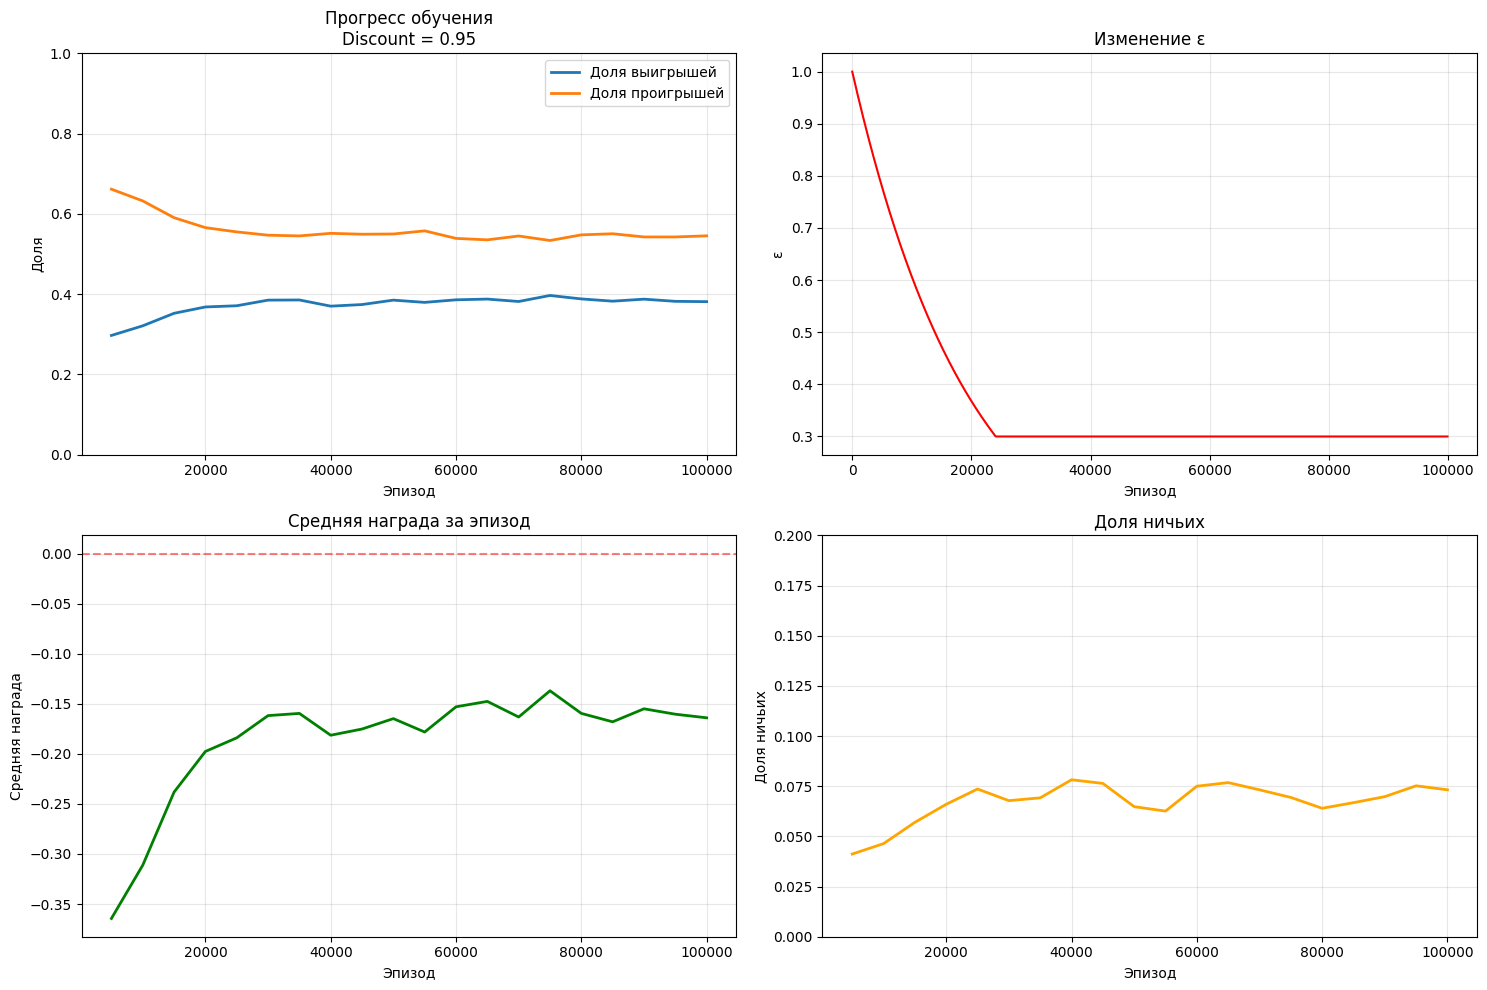

Тестирование стратегии: 100%|██████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 19874.51it/s]



Результаты тестирования на 10000 играх:
Выигрышей: 4322 (43.220%)
Проигрышей: 4892 (48.920%)
Ничьих: 786 (7.860%)

Эксперимент: Discount = 0.99
Размеры пространства состояний: (np.int64(32), np.int64(11), np.int64(2))
Количество состояний: 704
Количество возможных действий: 2
Размер Q-таблицы: (32, 11, 2, 2)
Начальное значение ε: 1.0
Начальные значения Q-функции: 0.0


Обучение ε-greedy:   3%|█▊                                                     | 3325/100000 [00:00<00:02, 33245.91it/s]


Эпизод 5000:
  ε: 0.7788
  Доля выигрышей: 29.720% (1486/5000)
  Доля проигрышей: 66.160% (3308/5000)
  Доля ничьих: 4.120% (206/5000)
  Средняя награда: -0.364


Обучение ε-greedy:  10%|█████▎                                                 | 9621/100000 [00:00<00:03, 27864.26it/s]

...


Эпизод 85000:
  ε: 0.3000
  Доля выигрышей: 38.260% (1913/5000)
  Доля проигрышей: 54.240% (2712/5000)
  Доля ничьих: 7.500% (375/5000)
  Средняя награда: -0.160

Эпизод 90000:
  ε: 0.3000
  Доля выигрышей: 38.900% (1945/5000)
  Доля проигрышей: 53.940% (2697/5000)
  Доля ничьих: 7.160% (358/5000)
  Средняя награда: -0.150


Обучение ε-greedy:  99%|█████████████████████████████████████████████████████▌| 99284/100000 [00:04<00:00, 23625.97it/s]


Эпизод 95000:
  ε: 0.3000
  Доля выигрышей: 37.700% (1885/5000)
  Доля проигрышей: 54.860% (2743/5000)
  Доля ничьих: 7.440% (372/5000)
  Средняя награда: -0.172


Обучение ε-greedy: 100%|█████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 22254.58it/s]



Эпизод 100000:
  ε: 0.3000
  Доля выигрышей: 37.180% (1859/5000)
  Доля проигрышей: 55.300% (2765/5000)
  Доля ничьих: 7.520% (376/5000)
  Средняя награда: -0.181


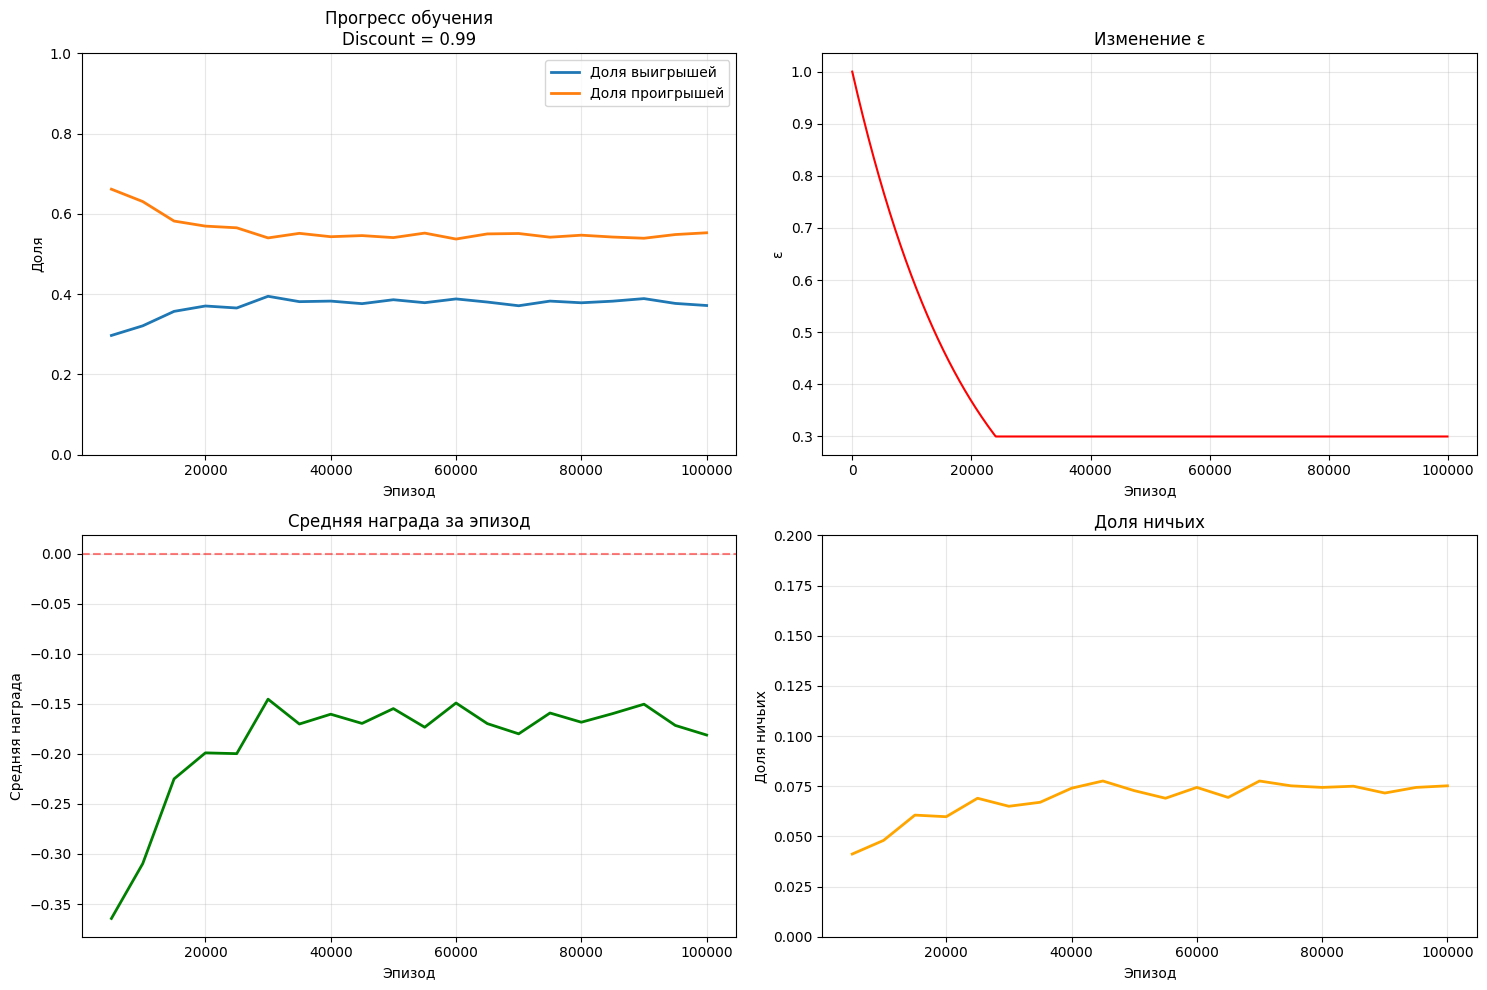

Тестирование стратегии: 100%|██████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 20013.24it/s]



Результаты тестирования на 10000 играх:
Выигрышей: 4285 (42.850%)
Проигрышей: 4851 (48.510%)
Ничьих: 864 (8.640%)


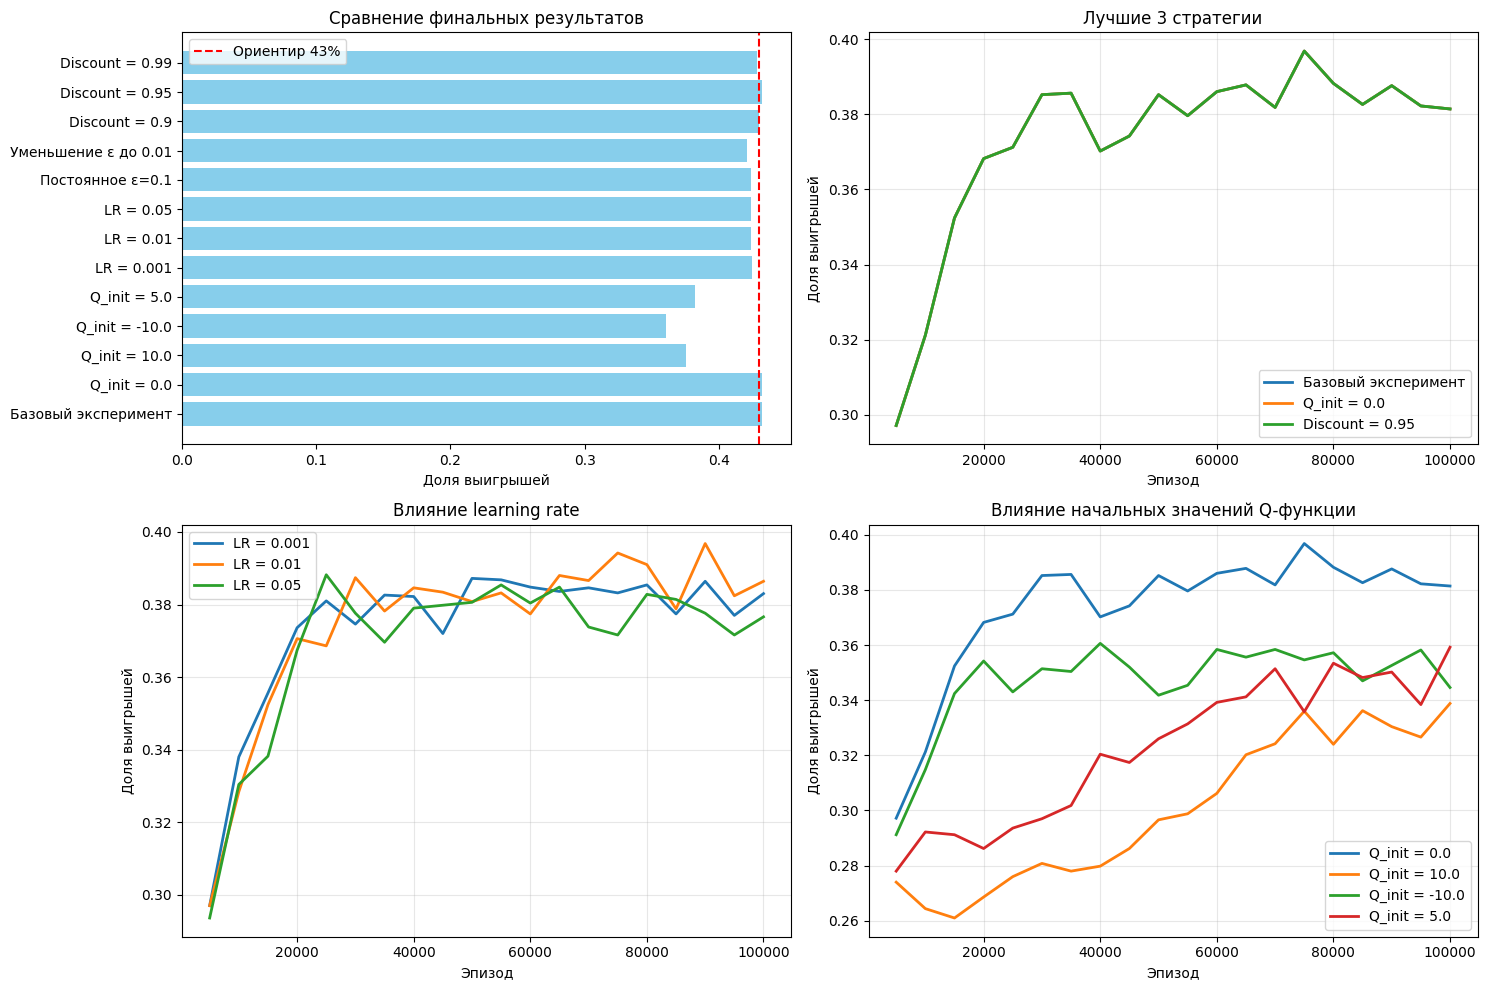


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
 1. Базовый эксперимент            | Win rate: 43.220% | Final ε: 0.3000 | LR: 0.0050 | Q_init: 0.0
 2. Q_init = 0.0                   | Win rate: 43.220% | Final ε: 0.3000 | LR: 0.0050 | Q_init: 0.0
 3. Q_init = 10.0                  | Win rate: 37.510% | Final ε: 0.3000 | LR: 0.0050 | Q_init: 10.0
 4. Q_init = -10.0                 | Win rate: 36.060% | Final ε: 0.3000 | LR: 0.0050 | Q_init: -10.0
 5. Q_init = 5.0                   | Win rate: 38.220% | Final ε: 0.3000 | LR: 0.0050 | Q_init: 5.0
 6. LR = 0.001                     | Win rate: 42.490% | Final ε: 0.3000 | LR: 0.0010 | Q_init: 0.0
 7. LR = 0.01                      | Win rate: 42.400% | Final ε: 0.3000 | LR: 0.0100 | Q_init: 0.0
 8. LR = 0.05                      | Win rate: 42.380% | Final ε: 0.3000 | LR: 0.0500 | Q_init: 0.0
 9. Постоянное ε=0.1               | Win rate: 42.400% | Final ε: 0.1000 | LR: 0.0050 | Q_init: 0.0
10. Уменьшение ε до 0.01           | Win rate: 42.080% | Final ε: 0.

In [5]:
@dataclass
class Config:
    discount: float = 0.95
    lr: float = 0.005
    n_episodes: int = 100_000
    epsilon: float = 1.0
    final_epsilon: float = 0.3
    print_every: int = 5_000
    epsilon_decay: float = 0.99995
    q_init_value: float = 0.0
    seed: int = 42


class EpsilonGreedyAgent:
    def __init__(self, env: gym.Env, config: Config) -> None:
        self.env = env
        self.cfg = config
        self.current_epsilon = config.epsilon
        self.rng = np.random.default_rng(config.seed)

        self.state_shape = tuple(space.n for space in self.env.observation_space.spaces)
        self.n_actions = self.env.action_space.n
        self._create_q_table()

        self.env.reset(seed=self.cfg.seed)
        self.env.action_space.seed(self.cfg.seed)

        print(f"Размеры пространства состояний: {self.state_shape}")
        print(f"Количество состояний: {int(np.prod(self.state_shape))}")
        print(f"Количество возможных действий: {self.n_actions}")
        print(f"Размер Q-таблицы: {self.q_table.shape}")
        print(f"Начальное значение ε: {self.current_epsilon}")
        print(f"Начальные значения Q-функции: {self.cfg.q_init_value}")

    def _create_q_table(self):
        self.q_table = np.full(
            (*self.state_shape, self.n_actions),
            self.cfg.q_init_value,
            dtype=np.float64
        )

    def _decay_epsilon(self):
        # Уменьшение ε один раз после каждого эпизода.
        self.current_epsilon = max(
            self.cfg.final_epsilon,
            self.current_epsilon * self.cfg.epsilon_decay
        )

    def get_action(self, state: tuple, training: bool = True) -> int:
        player_sum, dealer_card, usable_ace = state

        # ε-greedy стратегия используется только во время обучения.
        if training and self.rng.random() < self.current_epsilon:
            return int(self.rng.integers(self.n_actions))

        q_values = self.q_table[player_sum, dealer_card, int(usable_ace), :]
        max_q = np.max(q_values)
        best_actions = np.flatnonzero(q_values == max_q)
        return int(self.rng.choice(best_actions))

    def update_q_table(
        self,
        state: tuple,
        new_state: tuple,
        reward: float,
        action: int,
        done: bool
    ) -> None:
        player_sum, dealer_card, usable_ace = state
        new_player_sum, new_dealer_card, new_usable_ace = new_state

        current_q = self.q_table[player_sum, dealer_card, int(usable_ace), action]

        if done:
            future_q = 0.0
        else:
            future_q = np.max(
                self.q_table[new_player_sum, new_dealer_card, int(new_usable_ace), :]
            )

        td_target = reward + self.cfg.discount * future_q
        self.q_table[player_sum, dealer_card, int(usable_ace), action] = (
            current_q + self.cfg.lr * (td_target - current_q)
        )

    def run_episode(self, training: bool = True) -> float:
        state, _ = self.env.reset()

        while True:
            action = self.get_action(state, training=training)
            new_state, reward, terminated, truncated, _ = self.env.step(action)
            done = terminated or truncated

            if training:
                self.update_q_table(state, new_state, reward, action, done)

            state = new_state

            if done:
                return float(reward)

    def train(self):
        stats = []
        recent_rewards = deque(maxlen=self.cfg.print_every)
        epsilon_history = []

        for ep in tqdm(range(self.cfg.n_episodes), desc="Обучение ε-greedy"):
            reward = self.run_episode(training=True)
            recent_rewards.append(reward)

            # ε уменьшается один раз на эпизод, а не после каждого действия.
            self._decay_epsilon()

            if ep % 100 == 0:
                epsilon_history.append((ep + 1, self.current_epsilon))

            if (ep + 1) % self.cfg.print_every == 0:
                wins = sum(1 for r in recent_rewards if r == 1)
                losses = sum(1 for r in recent_rewards if r == -1)
                draws = sum(1 for r in recent_rewards if r == 0)

                total_games = len(recent_rewards)
                win_rate = wins / total_games
                loss_rate = losses / total_games
                draw_rate = draws / total_games

                stats.append({
                    'episode': ep + 1,
                    'win_rate': win_rate,
                    'loss_rate': loss_rate,
                    'draw_rate': draw_rate,
                    'epsilon': self.current_epsilon,
                    'avg_reward': np.mean(recent_rewards)
                })

                print(f"\nЭпизод {ep + 1}:")
                print(f"  ε: {self.current_epsilon:.4f}")
                print(f"  Доля выигрышей: {win_rate:.3%} ({wins}/{total_games})")
                print(f"  Доля проигрышей: {loss_rate:.3%} ({losses}/{total_games})")
                print(f"  Доля ничьих: {draw_rate:.3%} ({draws}/{total_games})")
                print(f"  Средняя награда: {np.mean(recent_rewards):.3f}")

        return stats, epsilon_history

    def test_policy(self, n_games: int = 10_000) -> float:
        """Тестирование обученной стратегии без исследования."""
        wins = 0
        losses = 0
        draws = 0

        eval_env = gym.make('Blackjack-v1', sab=True)

        for game_idx in tqdm(range(n_games), desc="Тестирование стратегии"):
            state, _ = eval_env.reset(seed=self.cfg.seed + 10_000 + game_idx)

            while True:
                player_sum, dealer_card, usable_ace = state
                q_values = self.q_table[player_sum, dealer_card, int(usable_ace), :]
                max_q = np.max(q_values)
                best_actions = np.flatnonzero(q_values == max_q)
                action = int(self.rng.choice(best_actions))

                state, reward, terminated, truncated, _ = eval_env.step(action)

                if terminated or truncated:
                    if reward == 1:
                        wins += 1
                    elif reward == -1:
                        losses += 1
                    else:
                        draws += 1
                    break

        eval_env.close()

        win_rate = wins / n_games
        loss_rate = losses / n_games
        draw_rate = draws / n_games

        print(f"\nРезультаты тестирования на {n_games} играх:")
        print(f"Выигрышей: {wins} ({win_rate:.3%})")
        print(f"Проигрышей: {losses} ({loss_rate:.3%})")
        print(f"Ничьих: {draws} ({draw_rate:.3%})")

        return win_rate


def run_experiment(config, experiment_name):
    """Запуск одного эксперимента с заданной конфигурацией."""
    print(f"\n{'='*60}")
    print(f"Эксперимент: {experiment_name}")
    print(f"{'='*60}")

    env = gym.make('Blackjack-v1', sab=True)
    agent = EpsilonGreedyAgent(env, config)

    stats, epsilon_history = agent.train()

    # Визуализация прогресса
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    episodes = [s['episode'] for s in stats]
    win_rates = [s['win_rate'] for s in stats]
    loss_rates = [s['loss_rate'] for s in stats]

    axes[0, 0].plot(episodes, win_rates, label='Доля выигрышей', linewidth=2)
    axes[0, 0].plot(episodes, loss_rates, label='Доля проигрышей', linewidth=2)
    axes[0, 0].set_xlabel('Эпизод')
    axes[0, 0].set_ylabel('Доля')
    axes[0, 0].set_title(f'Прогресс обучения\n{experiment_name}')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_ylim(0, 1)

    eps_episodes = [x[0] for x in epsilon_history]
    eps_values = [x[1] for x in epsilon_history]
    axes[0, 1].plot(eps_episodes, eps_values, color='red')
    axes[0, 1].set_xlabel('Эпизод')
    axes[0, 1].set_ylabel('ε')
    axes[0, 1].set_title('Изменение ε')
    axes[0, 1].grid(True, alpha=0.3)

    avg_rewards = [s['avg_reward'] for s in stats]
    axes[1, 0].plot(episodes, avg_rewards, color='green', linewidth=2)
    axes[1, 0].set_xlabel('Эпизод')
    axes[1, 0].set_ylabel('Средняя награда')
    axes[1, 0].set_title('Средняя награда за эпизод')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)

    draw_rates = [s['draw_rate'] for s in stats]
    axes[1, 1].plot(episodes, draw_rates, color='orange', linewidth=2)
    axes[1, 1].set_xlabel('Эпизод')
    axes[1, 1].set_ylabel('Доля ничьих')
    axes[1, 1].set_title('Доля ничьих')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_ylim(0, 0.2)

    plt.tight_layout()
    plt.show()

    win_rate = agent.test_policy(n_games=10_000)
    env.close()

    return {
        'name': experiment_name,
        'config': config,
        'final_win_rate': win_rate,
        'final_epsilon': agent.current_epsilon,
        'stats': stats
    }


def hyperparameter_study():
    """Исследование влияния гиперпараметров."""
    experiments = []

    # Все конфигурации используют один seed, чтобы сравнение было воспроизводимым.
    base_config = Config(seed=42)
    experiments.append(run_experiment(base_config, "Базовый эксперимент"))

    # Начальные значения Q-функции
    for q_init in [0.0, 10.0, -10.0, 5.0]:
        config = Config(q_init_value=q_init, seed=42)
        experiments.append(run_experiment(config, f"Q_init = {q_init}"))

    # Learning rate
    for lr in [0.001, 0.01, 0.05]:
        config = Config(lr=lr, seed=42)
        experiments.append(run_experiment(config, f"LR = {lr}"))

    # Стратегии ε
    config = Config(epsilon=0.1, final_epsilon=0.1, seed=42)
    experiments.append(run_experiment(config, "Постоянное ε=0.1"))

    config = Config(
        epsilon=0.5,
        final_epsilon=0.01,
        epsilon_decay=0.99995,
        seed=42
    )
    experiments.append(run_experiment(config, "Уменьшение ε до 0.01"))

    # Discount factor
    for discount in [0.9, 0.95, 0.99]:
        config = Config(discount=discount, seed=42)
        experiments.append(run_experiment(config, f"Discount = {discount}"))

    # Визуализация сравнения всех экспериментов
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    names = [exp['name'] for exp in experiments]
    all_win_rates = [exp['final_win_rate'] for exp in experiments]

    axes[0, 0].barh(names, all_win_rates, color='skyblue')
    axes[0, 0].set_xlabel('Доля выигрышей')
    axes[0, 0].set_title('Сравнение финальных результатов')
    axes[0, 0].axvline(x=0.43, color='r', linestyle='--', label='Ориентир 43%')
    axes[0, 0].legend()

    experiments_sorted = sorted(
        experiments,
        key=lambda x: x['final_win_rate'],
        reverse=True
    )[:3]

    for exp in experiments_sorted:
        episodes = [s['episode'] for s in exp['stats']]
        win_rates = [s['win_rate'] for s in exp['stats']]
        axes[0, 1].plot(episodes, win_rates, label=exp['name'], linewidth=2)

    axes[0, 1].set_xlabel('Эпизод')
    axes[0, 1].set_ylabel('Доля выигрышей')
    axes[0, 1].set_title('Лучшие 3 стратегии')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    lr_exps = [exp for exp in experiments if 'LR =' in exp['name']]
    for exp in lr_exps:
        episodes = [s['episode'] for s in exp['stats']]
        win_rates = [s['win_rate'] for s in exp['stats']]
        axes[1, 0].plot(episodes, win_rates, label=exp['name'], linewidth=2)

    axes[1, 0].set_xlabel('Эпизод')
    axes[1, 0].set_ylabel('Доля выигрышей')
    axes[1, 0].set_title('Влияние learning rate')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    q_init_exps = [exp for exp in experiments if 'Q_init =' in exp['name']]
    for exp in q_init_exps:
        episodes = [s['episode'] for s in exp['stats']]
        win_rates = [s['win_rate'] for s in exp['stats']]
        axes[1, 1].plot(episodes, win_rates, label=exp['name'], linewidth=2)

    axes[1, 1].set_xlabel('Эпизод')
    axes[1, 1].set_ylabel('Доля выигрышей')
    axes[1, 1].set_title('Влияние начальных значений Q-функции')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n" + "="*80)
    print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
    print("="*80)
    for i, exp in enumerate(experiments, 1):
        print(
            f"{i:2}. {exp['name']:30} | "
            f"Win rate: {exp['final_win_rate']:.3%} | "
            f"Final ε: {exp['final_epsilon']:.4f} | "
            f"LR: {exp['config'].lr:.4f} | "
            f"Q_init: {exp['config'].q_init_value}"
        )

    return experiments


def main():
    print("Исследование ε-greedy Q-learning для Blackjack")
    print("Изучение влияния гиперпараметров и инициализации Q-функции\n")

    experiments = hyperparameter_study()

    best_exp = max(experiments, key=lambda x: x['final_win_rate'])
    worst_exp = min(experiments, key=lambda x: x['final_win_rate'])

    lr_exps = [exp for exp in experiments if 'LR =' in exp['name']]
    q_init_exps = [exp for exp in experiments if 'Q_init =' in exp['name']]
    discount_exps = [exp for exp in experiments if 'Discount =' in exp['name']]
    epsilon_exps = [
        exp for exp in experiments
        if ('ε=' in exp['name'] or 'ε до' in exp['name'])
    ]

    best_lr = max(lr_exps, key=lambda x: x['final_win_rate'])
    best_q_init = max(q_init_exps, key=lambda x: x['final_win_rate'])
    best_discount = max(discount_exps, key=lambda x: x['final_win_rate'])
    best_epsilon = max(epsilon_exps, key=lambda x: x['final_win_rate'])

    print(f"\n{'='*60}")
    print(f"Лучший результат: {best_exp['name']} - {best_exp['final_win_rate']:.3%}")
    print(f"Худший результат: {worst_exp['name']} - {worst_exp['final_win_rate']:.3%}")

    print(f"\n{'='*60}")
    print("ВЫВОДЫ ПО ПОЛУЧЕННЫМ РЕЗУЛЬТАТАМ:")
    print(
        f"1. Среди проверенных learning rate лучший: "
        f"{best_lr['config'].lr} ({best_lr['final_win_rate']:.3%})."
    )
    print(
        f"2. Среди проверенных инициализаций лучший Q_init: "
        f"{best_q_init['config'].q_init_value} "
        f"({best_q_init['final_win_rate']:.3%})."
    )
    print(
        f"3. Среди проверенных ε-стратегий лучший вариант: "
        f"{best_epsilon['name']} ({best_epsilon['final_win_rate']:.3%})."
    )
    print(
        f"4. Среди проверенных discount factor лучший: "
        f"{best_discount['config'].discount} "
        f"({best_discount['final_win_rate']:.3%})."
    )
    print(
        "5. Различия в долях побед небольшие; один запуск с фиксированным seed "
        "показывает тенденцию, но не доказывает статистически значимое превосходство."
    )


if __name__ == "__main__":
    main()


## Обратная связь
- [ ] Почта: d83073452@yandex.ru
- [ ] Gmail: 3073452@gmail.com
- [ ] Telegram: @sleepingzzzZ